# Separation between FK5 and ICRS

In [1]:
import numpy as np
import warnings
import matplotlib.pyplot as plt
from spectral_cube import SpectralCube, Projection
from astropy.modeling import models, fitting
from astropy.convolution import convolve_models
from astropy import units as u
from astropy.io import fits
import radio_beam
from radio_beam import Beam
import pandas as pd
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy.wcs.utils import pixel_to_skycoord

/Users/galagabits/miniconda3/envs/masers/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Code for fitting 2D Gaussians and storing measurements in a table, including SkyCoords.

In [2]:
#Accessing Cube Data
def fit_2dgaussian(directory, maser_table, freq, amplitude, x, y, x_stddev, y_stddev, 
    theta=np.pi/3, size=13, channel=0, cube=True, format='fits', table=True, source_name='None',
    fixed_xstddev=False, fixed_ystddev=False, fixed_theta=False):

    """
    Fit a 2D Gaussian to a cutout of a spectral cube or image.

    """

    if cube:
        
        cube = SpectralCube.read(directory, format=format)

        if channel is None:
            pass
        else:
            cube = cube[channel,:,:]

        cube_cutout = cube[y - size:y + size, x - size:x + size]
        yy, xx = cube_cutout.spatial_coordinate_map

        cord = cube.world[y,x]

        x_guess, y_guess = cord[1], cord[0]

    else:
        
        hdul = fits.open(directory)

        hdu = hdul[0]

        data_cube = hdul[0].data

        if data_cube.ndim == 4:
            data = data_cube[0, 0, :, :] * u.Jy/u.beam

        else:
            data = hdu.data * u.Jy/u.beam

        header = hdu.header

        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            ww = WCS(header)

        data_cutout = data[y - size:y + size, x - size:x + size]
        ypixel_grid, xpixel_grid = np.mgrid[y - size:y + size, x - size:x + size]
        
        # xx, yy = ww.pixel_to_world_values(xpixel_grid, ypixel_grid)

        # xx = (xx * u.deg)
        # yy = (yy * u.deg)

        # x_guess, y_guess = xx[size, size], ypixel_grid[size, size]

    p_init_gauss2D = models.Gaussian2D(x_mean=x, y_mean=y, amplitude=amplitude * (u.Jy/u.beam),
                                    x_stddev=(x_stddev), y_stddev=(y_stddev), theta=(theta)*u.rad)

    if fixed_xstddev:
        p_init_gauss2D.x_stddev.fixed = True

    if fixed_ystddev:
        p_init_gauss2D.y_stddev.fixed = True

    if fixed_theta:
        p_init_gauss2D.theta.fixed = True

    fit_p = fitting.LevMarLSQFitter()
    data_cutout[np.isnan(data_cutout)] = 0.

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        p_gauss2D = fit_p(p_init_gauss2D, xpixel_grid, ypixel_grid, data_cutout)

  
    cov = np.diag(fit_p.fit_info['param_cov'])
    errors = np.sqrt(cov)

    amplitude_error=np.format_float_scientific(errors[0],precision=9)
    x_mean_error=np.format_float_scientific(errors[1],precision=9)
    y_mean_error=np.format_float_scientific(errors[2],precision=9)
    x_stddev_error=np.format_float_scientific(errors[3],precision=9)
    y_stddev_error=np.format_float_scientific(errors[4],precision=9)
    theta_error=np.format_float_scientific(errors[5],precision=9)

    amplitude = np.format_float_scientific(p_gauss2D.amplitude[0],precision=9)
    x_mean = np.format_float_scientific(p_gauss2D.x_mean[0],precision=9)
    y_mean = np.format_float_scientific(p_gauss2D.y_mean[0],precision=9)
    x_stddev = np.format_float_scientific(p_gauss2D.x_stddev[0],precision=9)
    y_stddev = np.format_float_scientific(p_gauss2D.y_stddev[0],precision=9)
    theta = np.format_float_scientific(p_gauss2D.theta[0],precision=9)

                
    plt.figure(figsize=(20, 6))
    plt.suptitle(f"Source-{source_name} freq-{freq}", fontsize=18)

    plt.subplot(1, 3, 1)
    plt.title("Image")
    plt.imshow(data_cutout.value, origin='lower', cmap='inferno')
    plt.colorbar()

    plt.subplot(1, 3, 2)
    plt.title("Model")
    plt.imshow(p_gauss2D(xpixel_grid, ypixel_grid).value, origin='lower', cmap='inferno')
    plt.colorbar()

    plt.subplot(1, 3, 3)
    plt.title("Residual")
    plt.imshow(data_cutout.value - p_gauss2D(xpixel_grid, ypixel_grid).value, origin='lower', cmap='inferno')
    plt.colorbar(label='S (Jy)')

    plt.show()

    print("Parameter" + ' ' + 'Error' +"\n")
    print("Amplitude" +"\n")
    print(amplitude + ' ' + amplitude_error +"\n")

    print("x_mean"  +"\n")
    print(x_mean + ' ' + x_mean_error +"\n")

    print("y_mean" +"\n")
    print(y_mean + ' ' + y_mean_error +"\n")

    print("x_stddev" +"\n")
    print(x_stddev + ' ' + x_stddev_error +"\n")

    print("y_stddev" +"\n")
    print(y_stddev + ' ' + y_stddev_error +"\n")

    print("theta" +"\n")
    print(theta + ' ' + theta_error +"\n")

    # print('\n\nSkyCoord Conversion \n----------------- \n')
    # print("Parameter" + ' ' + 'Error' +"\n")

    skycoord = pixel_to_skycoord(float(x_mean), float(y_mean), ww)

    # error propagation? # Not sure if this is correct
    skycoord_error = pixel_to_skycoord(float(x_mean_error), float(y_mean_error), ww)


    ra_hms_str = skycoord.ra.to_string(unit=u.hour, sep=':', precision=4)
    dec_dms_str = skycoord.dec.to_string(unit=u.deg, sep=':', precision=4)


    print(skycoord_error)

    if table:
        new_row = pd.DataFrame({'source': [source_name] , 
            'freq': [freq], 'x_pix': [x], 'y_pix': [y], 'amplitude': [amplitude], 
            'amplitude_error': [amplitude_error], 'x_mean': [x_mean], 'x_mean_error': [x_mean_error], 
            'y_mean': [y_mean], 'y_mean_error': [y_mean_error], 
            'x_mean_sky': [skycoord.ra.deg], 'x_mean_sky_error': [skycoord_error.ra.deg],
            'y_mean_sky': [skycoord.dec.deg], 'y_mean_sky_error': [skycoord_error.dec.deg],
            'ra_hms': [ra_hms_str], 'dec_dms': [dec_dms_str],
            'SkyCoord' : [skycoord],
            'frame': [skycoord.frame.name], 
            'header': [ww]})
        maser_table = pd.concat([maser_table, new_row], ignore_index=True)

        return maser_table

### Positions for Sources in FK5 File

In [3]:
ca3_positions = pd.DataFrame(columns=['source','freq', 'x_pix', 'y_pix', 'amplitude', 'amplitude_error', 
'x_mean', 'x_mean_error', 'y_mean', 'y_mean_error', 'x_mean_sky', 'x_mean_sky_error', 
'y_mean_sky', 'y_mean_sky_error', 
'ra_hms', 'dec_dms',
'SkyCoord', 'frame', 'header'])

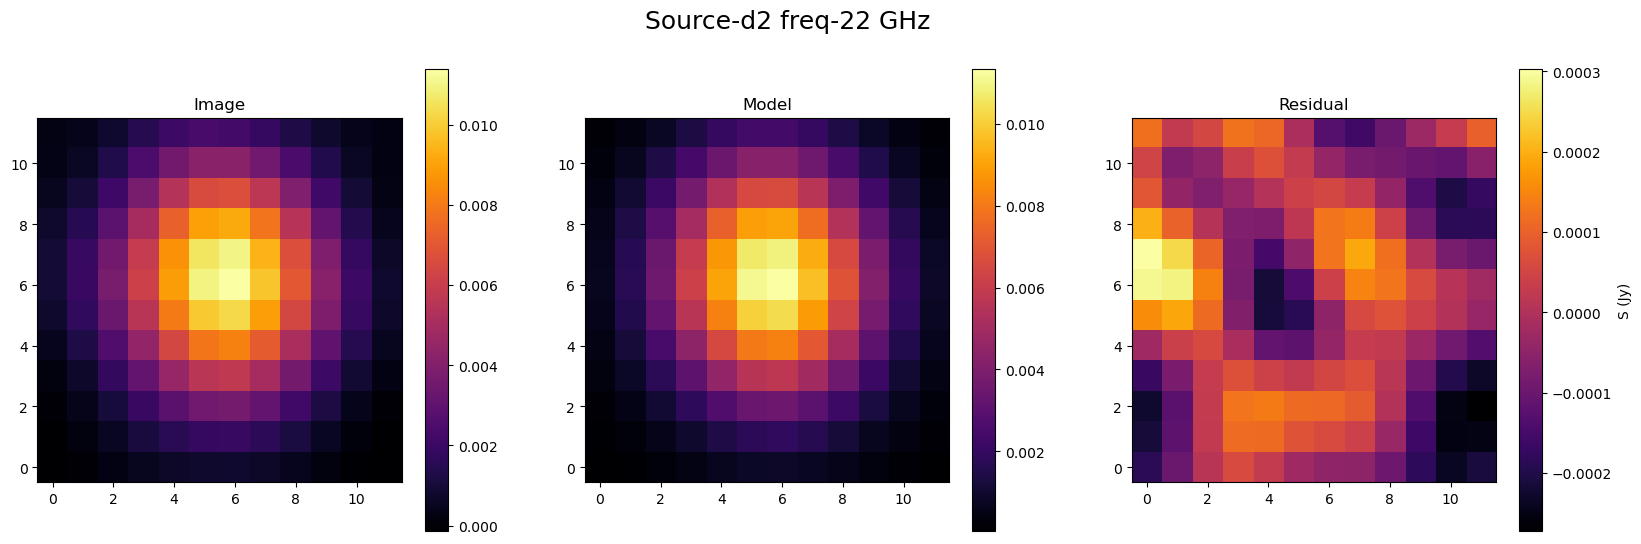

Parameter Error

Amplitude

1.151771352e-02 1.917987152e-04

x_mean

5.218615043e+03 3.887028644e-02

y_mean

4.959186077e+03 4.536435585e-02

x_stddev

2.35789366e+00 3.932334434e-02

y_stddev

2.722081357e+00 4.782805656e-02

theta

-9.35378897e+00 8.192741541e-02

<SkyCoord (ICRS): (ra, dec) in deg
    (290.93836833, 14.49733809)>


/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_36096/1725868750.py:160: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  maser_table = pd.concat([maser_table, new_row], ignore_index=True)


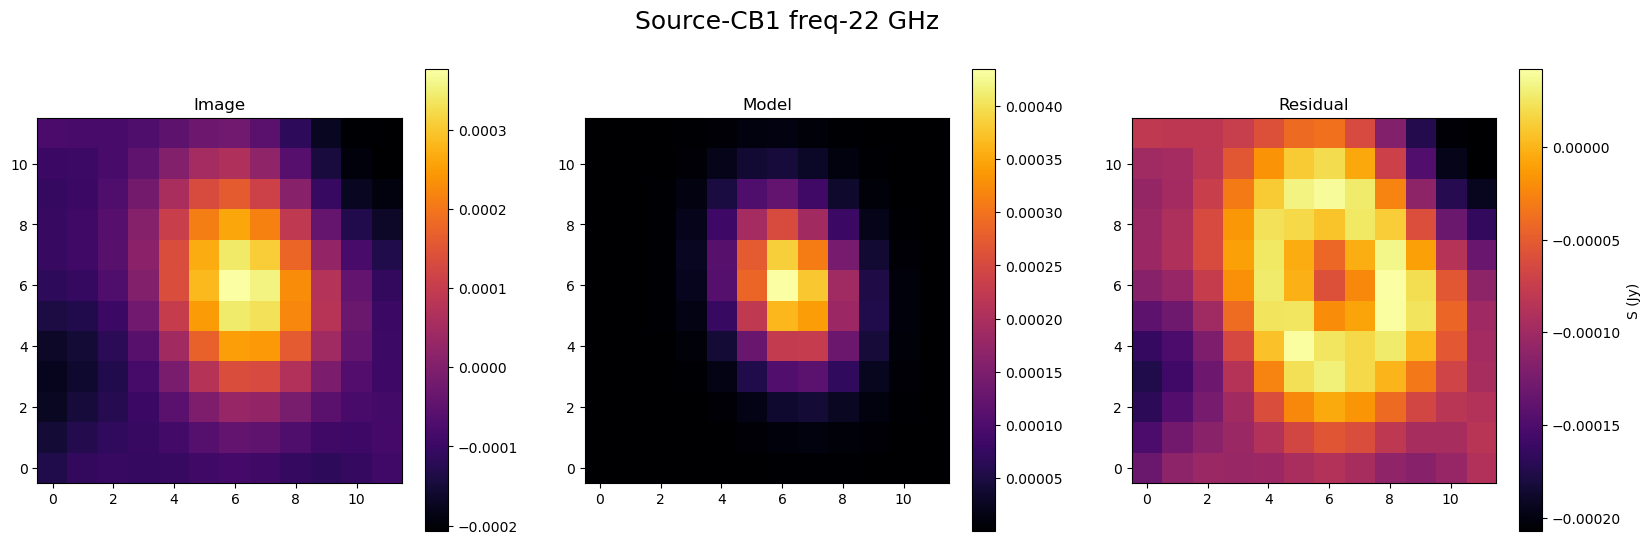

Parameter Error

Amplitude

4.418660395e-04 2.246677133e-04

x_mean

4.979243042e+03 6.90705741e-01

y_mean

5.000031297e+03 9.478908986e-01

x_stddev

1.897504114e+00 9.652688929e-01

y_stddev

1.313677093e+00 6.675111159e-01

theta

-1.312939080e+00 9.555356417e-01

<SkyCoord (ICRS): (ra, dec) in deg
    (290.93836552, 14.49734185)>


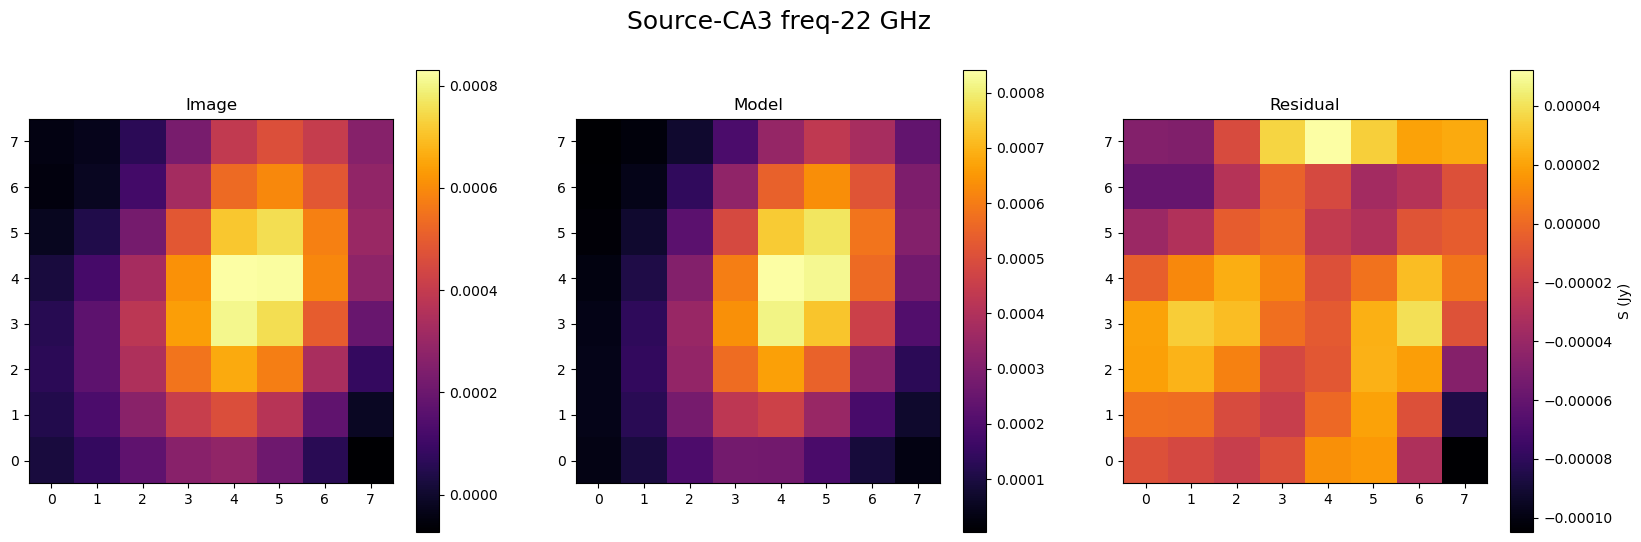

Parameter Error

Amplitude

8.69973245e-04 6.988139620e-05

x_mean

4.948413209e+03 1.426088778e-01

y_mean

5.014913612e+03 2.229965868e-01

x_stddev

2.738692985e+00 2.950405803e-01

y_stddev

1.609434402e+00 1.311656517e-01

theta

1.062651131e+01 1.128853044e-01

<SkyCoord (ICRS): (ra, dec) in deg
    (290.93836788, 14.49733883)>


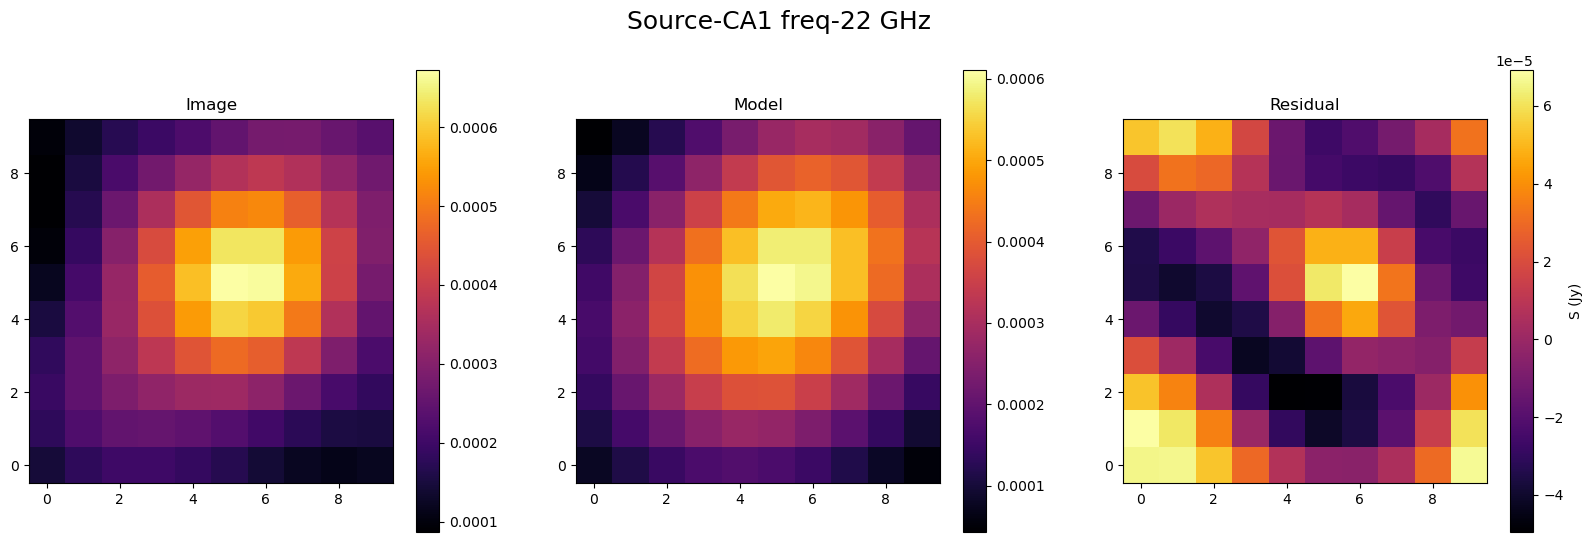

Parameter Error

Amplitude

6.131044792e-04 4.511103321e-05

x_mean

4.929290048e+03 2.572806573e-01

y_mean

5.023102075e+03 2.51185041e-01

x_stddev

3.640306692e+00 3.552392274e-01

y_stddev

2.839413584e+00 2.384574681e-01

theta

7.750857357e-01 2.728536159e-01

<SkyCoord (ICRS): (ra, dec) in deg
    (290.93836739, 14.49733895)>


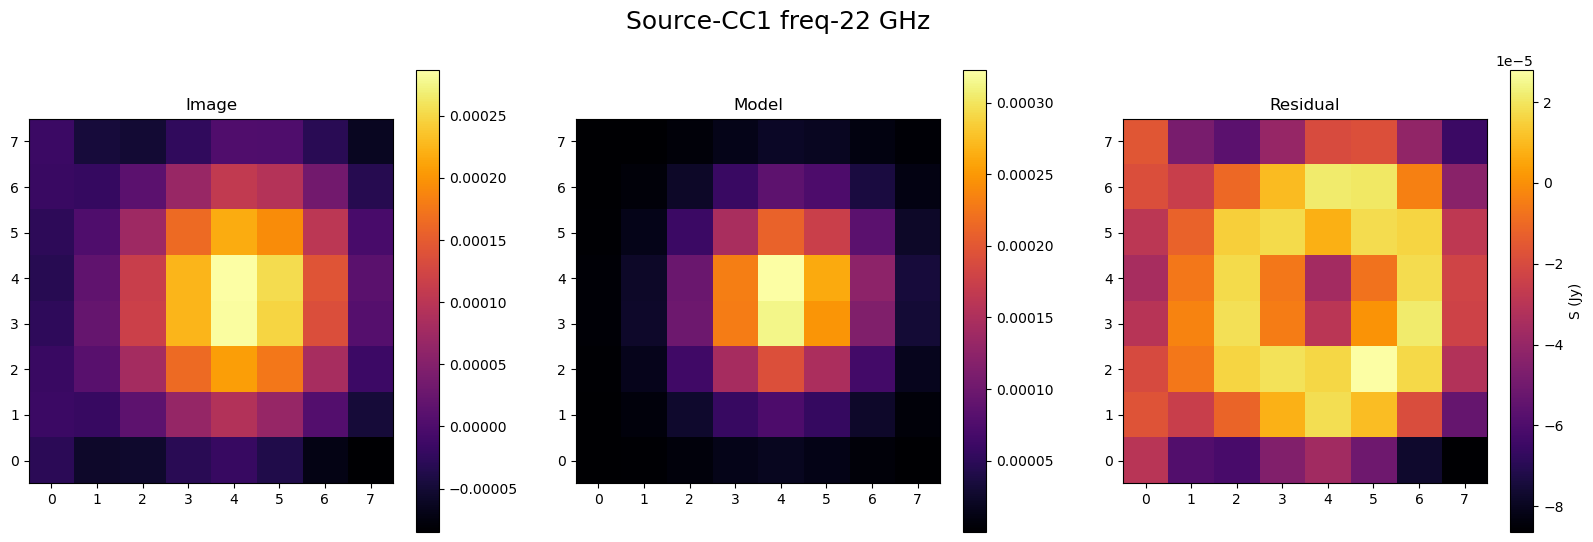

Parameter Error

Amplitude

3.381155236e-04 1.007333922e-04

x_mean

4.939095581e+03 4.048591057e-01

y_mean

4.932569758e+03 4.387020824e-01

x_stddev

1.349606058e+00 4.034727373e-01

y_stddev

1.485471079e+00 4.438114811e-01

theta

2.855111540e+00 2.194016295e+00

<SkyCoord (ICRS): (ra, dec) in deg
    (290.93836675, 14.49733973)>


In [4]:
directory3 = '/Volumes/GalagaResearch/Developer/masers/continuum/W51_North_KbandAarray_cont_spws_continuum_cal_clean_2terms_robust0_selfcal3.image.tt0.pbcor.fits'
# directory3 = '/Volumes/GalagaResearch/Developer/masers/continuum/modified_VLA/W51_North_KbandAarray_cont_spws_continuum_cal_clean_2terms_robust0_selfcal3.image.tt0.pbcor_ICRS_CRVAL_CA3_crval_change.fits'


# d2
ca3_positions = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions,
                                          amplitude=1, x=5219, y=4959, x_stddev=3, y_stddev=3, theta=np.pi/4, 
                                          size=6, freq='22 GHz', source_name='d2')

# CB1
ca3_positions = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions,
                                          amplitude=1, x=4979, y=5000, x_stddev=5.5, y_stddev=6, theta=np.pi/6, 
                                          size=6, freq='22 GHz', source_name='CB1')

# CA3
ca3_positions = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions,
                                          amplitude=1, x=4948, y=5015, x_stddev=3, y_stddev=3, theta=np.pi/4, 
                                          size=4, freq='22 GHz', source_name='CA3')


# This source does not fit well do to its close proximity to CA3
# CA2
# ca3_positions = fit_2dgaussian(table=True, cube=False, directory=directory3, 
#                                           maser_table=ca3_positions,
#                                           amplitude=0.001, x=4949, y=5021, x_stddev=2.5, y_stddev=2.5, theta=np.pi, 
#                                           size=4, freq='22 GHz', source_name='CA2')


# CA1
ca3_positions = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions,
                                          amplitude=.001, x=4929, y=5023, x_stddev=2.5, y_stddev=2.5, theta=np.pi/4, 
                                          size=5, freq='22 GHz', source_name='CA1')

# CC1
ca3_positions = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions,
                                          amplitude=.001, x=4939, y=4933, x_stddev=3.5, y_stddev=3.5, theta=np.pi, 
                                          size=4, freq='22 GHz', source_name='CC1')

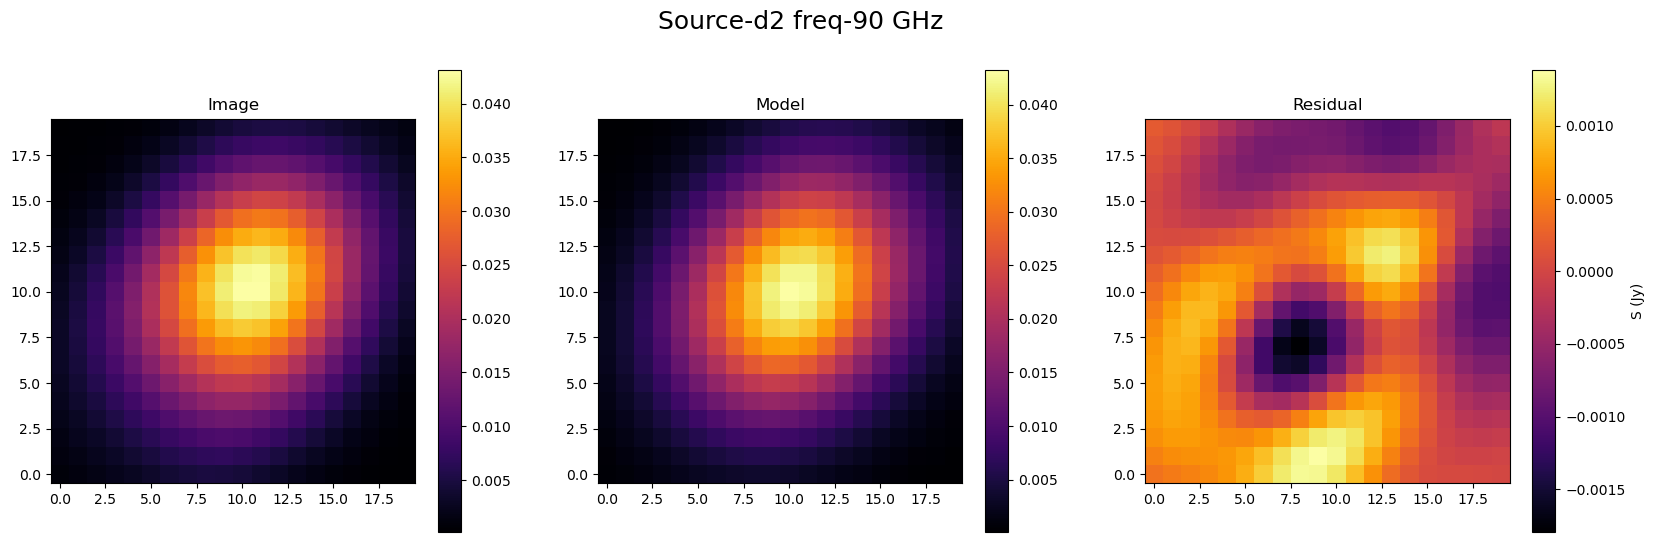

Parameter Error

Amplitude

4.334628767e-02 6.406366511e-04

x_mean

7.628300477e+03 6.352709685e-02

y_mean

7.226089485e+03 6.643789566e-02

x_stddev

3.935790551e+00 5.865414704e-02

y_stddev

4.867255856e+00 7.414817502e-02

theta

5.599936144e+00 5.03747949e-02

<SkyCoord (ICRS): (ra, dec) in deg
    (290.93122782, 14.50395801)>


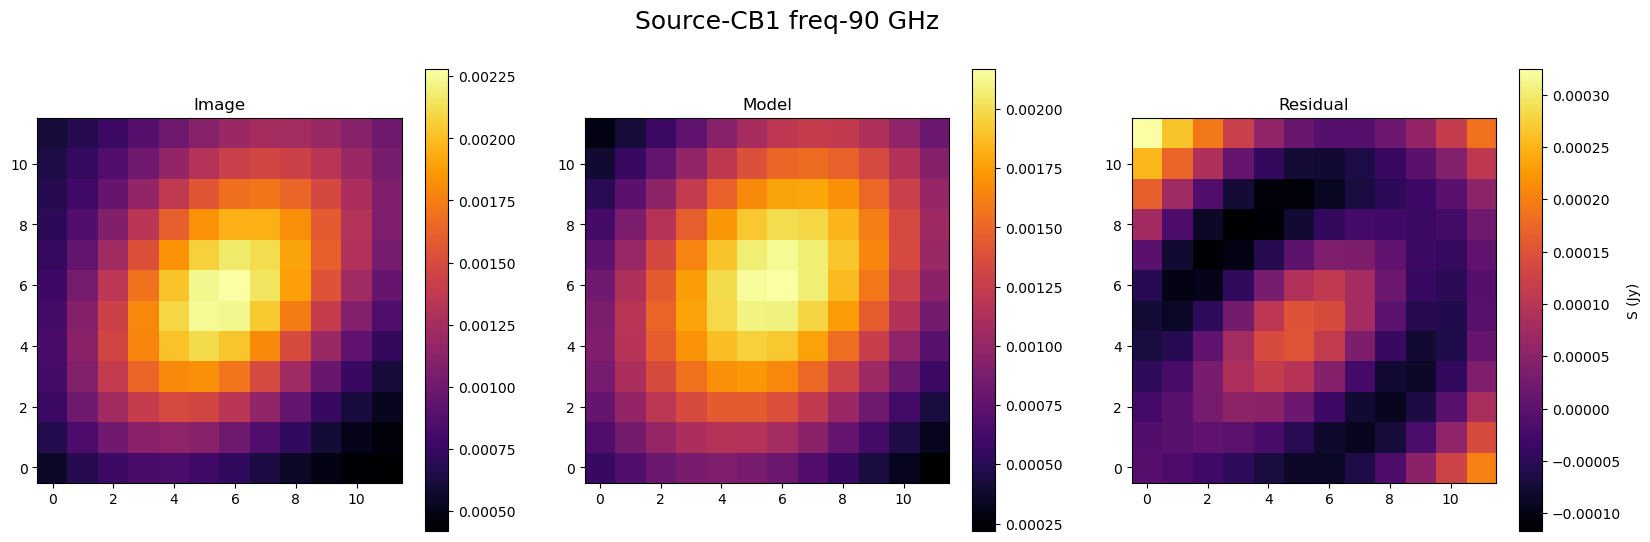

Parameter Error

Amplitude

2.173482568e-03 8.966578428e-05

x_mean

7.114766666e+03 1.873506309e-01

y_mean

7.311140702e+03 2.105421575e-01

x_stddev

5.129134890e+00 3.315953313e-01

y_stddev

3.727641455e+00 1.842769858e-01

theta

8.914323448e-01 1.323095985e-01

<SkyCoord (ICRS): (ra, dec) in deg
    (290.93122758, 14.50395829)>


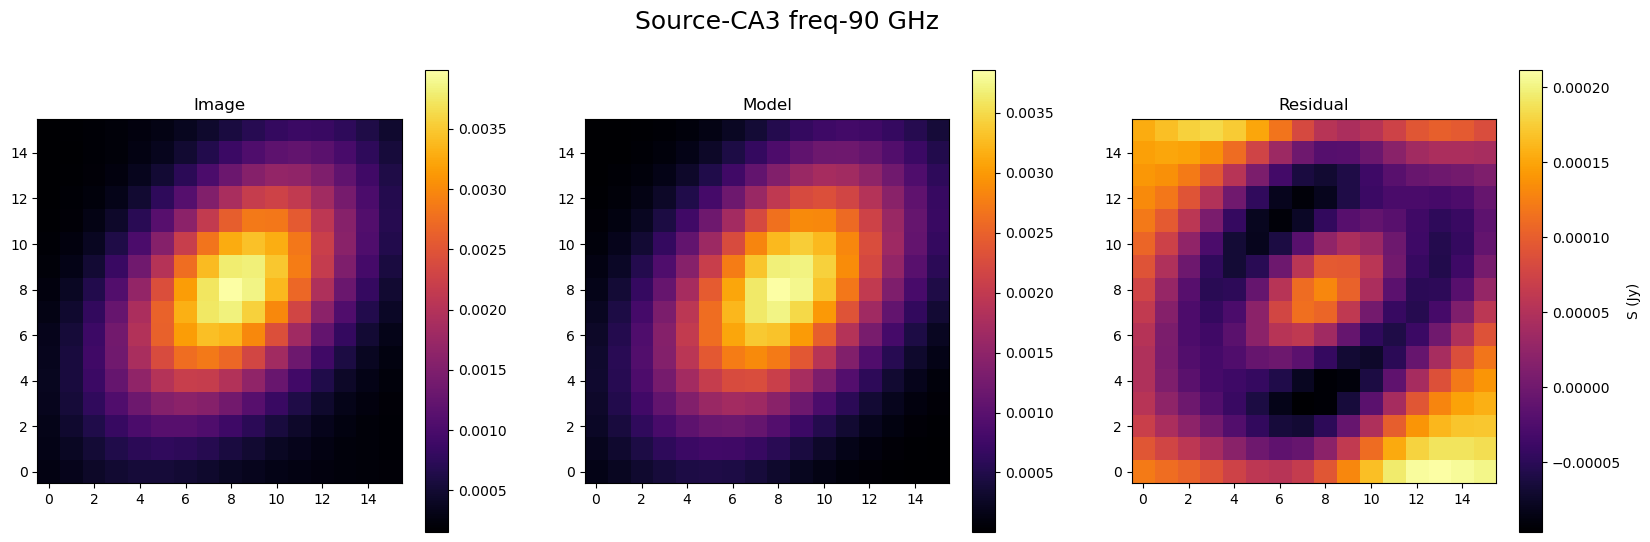

Parameter Error

Amplitude

3.864660335e-03 9.373147247e-05

x_mean

7.04720399e+03 8.854048944e-02

y_mean

7.342019719e+03 9.496941747e-02

x_stddev

4.557544129e+00 1.184819616e-01

y_stddev

2.853366386e+00 6.933071966e-02

theta

8.597357339e-01 3.700291007e-02

<SkyCoord (ICRS): (ra, dec) in deg
    (290.93122777, 14.50395807)>


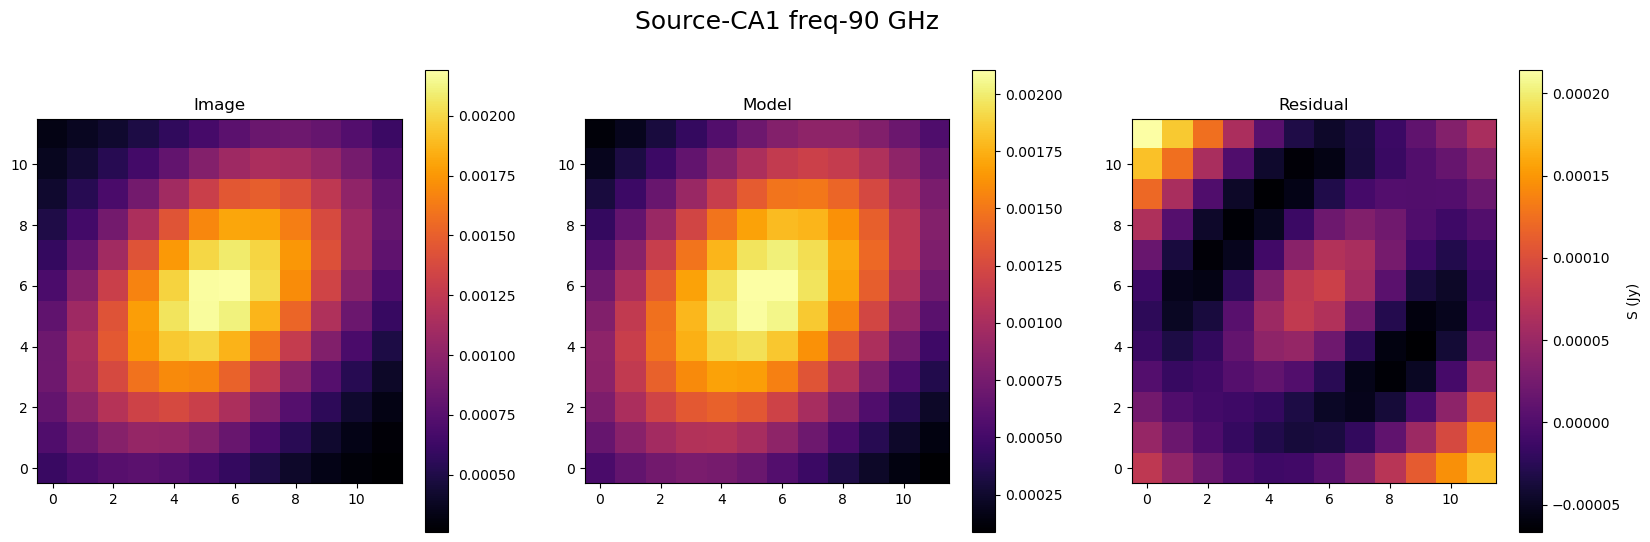

Parameter Error

Amplitude

2.128559589e-03 6.407895672e-05

x_mean

7.007404004e+03 1.244989264e-01

y_mean

7.360686341e+03 1.227562253e-01

x_stddev

4.719123603e+00 1.953564875e-01

y_stddev

3.155077569e+00 1.029586247e-01

theta

7.708248869e-01 6.667095644e-02

<SkyCoord (ICRS): (ra, dec) in deg
    (290.9312277, 14.50395812)>


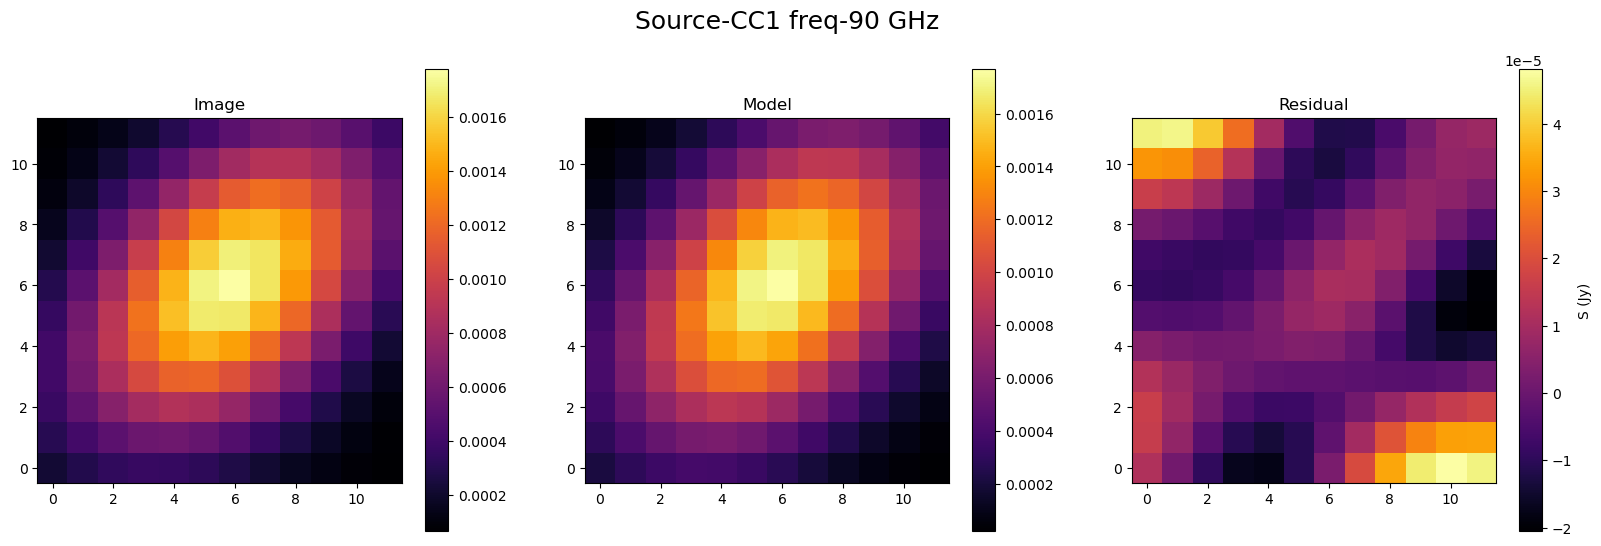

Parameter Error

Amplitude

1.76969183e-03 1.845949664e-05

x_mean

7.027847385e+03 3.562377766e-02

y_mean

7.167033011e+03 3.648030928e-02

x_stddev

2.629451691e+00 2.817203747e-02

y_stddev

4.081073906e+00 5.090712011e-02

theta

2.375147895e+00 1.862164016e-02

<SkyCoord (ICRS): (ra, dec) in deg
    (290.93122788, 14.50395796)>


In [5]:
directory3 = '/Volumes/GalagaResearch/Developer/masers/continuum/w51n.spw0thru19.14500.robust0.thr0.075mJy.mfs.I.startmod.selfcal7.image.tt0.pbcor.fits'



# d2
ca3_positions = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions,
                                          amplitude=5e-2, x=7628, y=7226, x_stddev=12, y_stddev=12, theta=11*np.pi/6, 
                                          size=10, freq='90 GHz', source_name='d2')

# CB1
ca3_positions = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions,
                                          amplitude=3e-2, x=7115, y=7311, x_stddev=4, y_stddev=6, theta=np.pi/4, 
                                          size=6, freq='90 GHz', source_name='CB1')

# CA3
ca3_positions = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions,
                                          amplitude=1, x=7047, y=7342, x_stddev=9, y_stddev=9, theta=np.pi/4, 
                                          size=8, freq='90 GHz', source_name='CA3')


# This source does not fit well do to its close proximity to CA3
# CA2
# ca3_positions = fit_2dgaussian(table=True, cube=False, directory=directory3, 
#                                           maser_table=ca3_positions,
#                                           amplitude=0.001, x=4949, y=5021, x_stddev=2.5, y_stddev=2.5, theta=np.pi, 
#                                           size=4, freq='22 GHz', source_name='CA2')


# CA1
ca3_positions = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions,
                                          amplitude=.001, x=7008, y=7361, x_stddev=7, y_stddev=7, theta=np.pi/4, 
                                          size=6, freq='90 GHz', source_name='CA1')

# CC1
ca3_positions = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions,
                                          amplitude=.001, x=7028, y=7167, x_stddev=9, y_stddev=9, theta=np.pi, 
                                          size=6, freq='90 GHz', source_name='CC1')

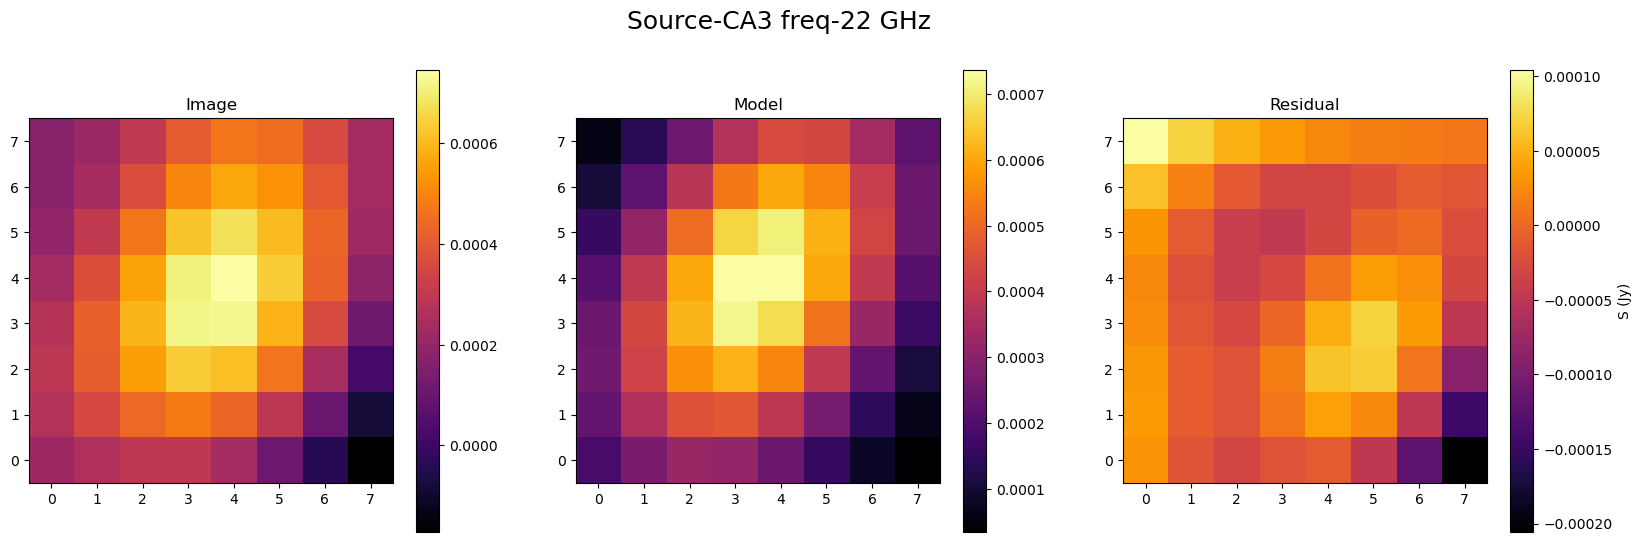

Parameter Error

Amplitude

7.564889207e-04 9.981267302e-05

x_mean

3.444824349e+02 3.097854847e-01

y_mean

4.159193021e+02 4.438426032e-01

x_stddev

3.261179270e+00 6.689154755e-01

y_stddev

2.044289294e+00 2.859738172e-01

theta

1.08016316e+00 2.433935022e-01

<SkyCoord (FK5: equinox=2000.0): (ra, dec) in deg
    (290.91845561, 14.51661838)>


/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_36096/1725868750.py:160: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  maser_table = pd.concat([maser_table, new_row], ignore_index=True)


In [6]:
ca3_positions_Kband_size800 = pd.DataFrame(columns=['source','freq', 'x_pix', 'y_pix', 'amplitude', 'amplitude_error', 
'x_mean', 'x_mean_error', 'y_mean', 'y_mean_error', 'x_mean_sky', 'x_mean_sky_error', 
'y_mean_sky', 'y_mean_sky_error', 
'ra_hms', 'dec_dms',
'SkyCoord', 'frame', 'header'])

directory3 = '/Volumes/GalagaResearch/Developer/masers/continuum/W51North_Kband_continuum_aug02.image.fits'

ca3_positions_Kband_size800 = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions_Kband_size800,
                                          amplitude=7.5e-4, x=345, y=416, x_stddev=2.5, y_stddev=3, theta=np.pi/4, 
                                          size=4, freq='22 GHz', source_name='CA3')

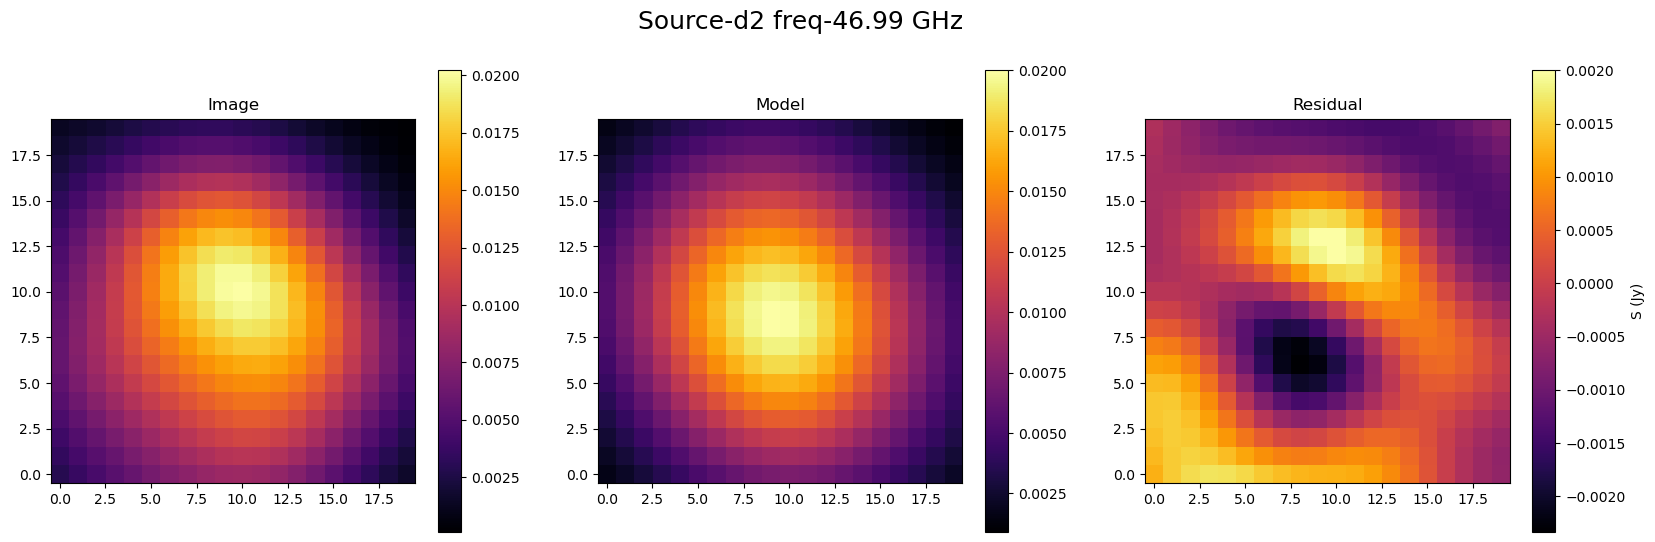

Parameter Error

Amplitude

2.008847220e-02 7.409843248e-04

x_mean

8.157326343e+03 2.127037009e-01

y_mean

7.379601716e+03 2.279344148e-01

x_stddev

5.666115271e+00 2.334458272e-01

y_stddev

6.235873557e+00 2.728590882e-01

theta

3.683851121e+00 3.190775139e-01

<SkyCoord (ICRS): (ra, dec) in deg
    (290.92760945, 14.50775562)>


/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_36096/1725868750.py:160: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  maser_table = pd.concat([maser_table, new_row], ignore_index=True)


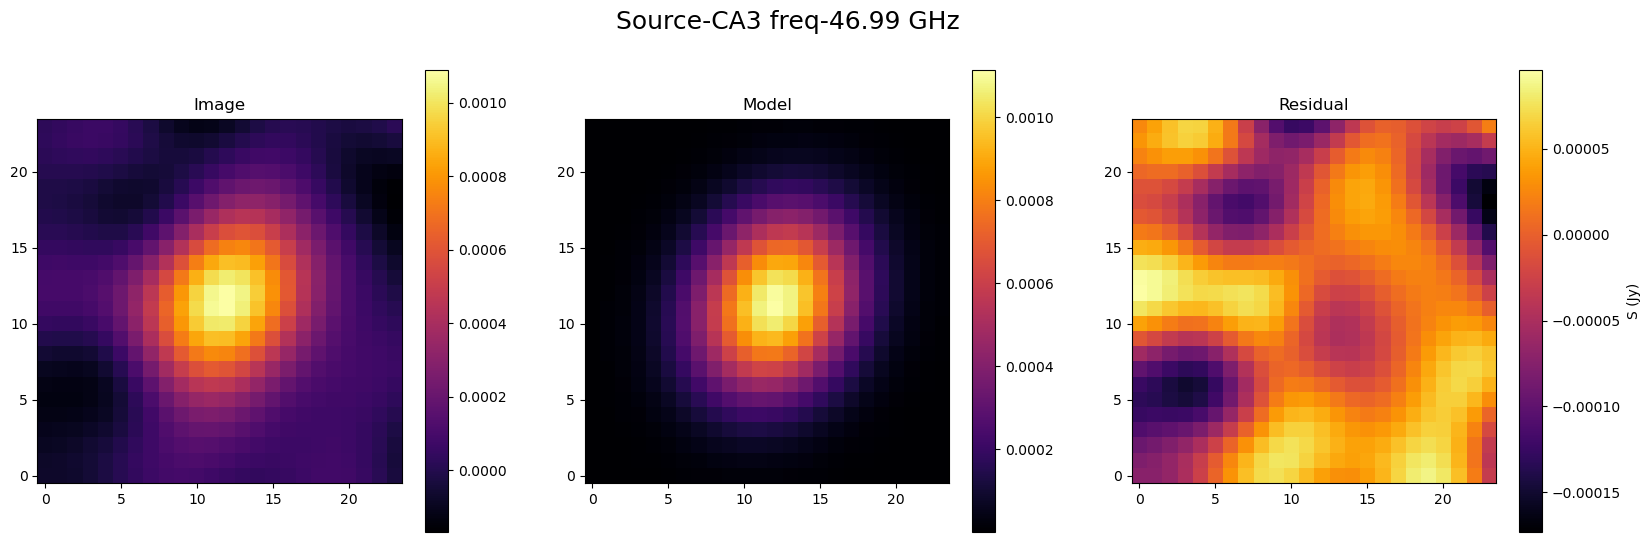

Parameter Error

Amplitude

1.118561057e-03 6.902485057e-05

x_mean

7.345059411e+03 2.223309533e-01

y_mean

7.543367160e+03 2.494930593e-01

x_stddev

4.194490305e+00 2.591225626e-01

y_stddev

3.429205715e+00 2.115685415e-01

theta

1.051719974e+01 2.152951863e-01

<SkyCoord (ICRS): (ra, dec) in deg
    (290.92760943, 14.50775565)>


In [7]:
ca3_positions_Qband = pd.DataFrame(columns=['source','freq', 'x_pix', 'y_pix', 'amplitude', 'amplitude_error', 
'x_mean', 'x_mean_error', 'y_mean', 'y_mean_error', 'x_mean_sky', 'x_mean_sky_error', 
'y_mean_sky', 'y_mean_sky_error', 
'ra_hms', 'dec_dms',
'SkyCoord', 'frame', 'header'])

directory3 = '/Volumes/GalagaResearch/Developer/masers/continuum/W51_North_QbandAarray_cont_spws_continuum_cal_clean_2terms_robust0_selfcal4_final.image.tt0.pbcor.fits'

ca3_positions_Qband = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions_Qband,
                                          amplitude=1, x=8158, y=7381, x_stddev=2, y_stddev=3, theta=np.pi/3, 
                                          size=10, freq='46.99 GHz', source_name='d2')

ca3_positions_Qband = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions_Qband,
                                          amplitude=1, x=7345, y=7544, x_stddev=3, y_stddev=3, theta=np.pi/4, 
                                          size=12, freq='46.99 GHz', source_name='CA3')

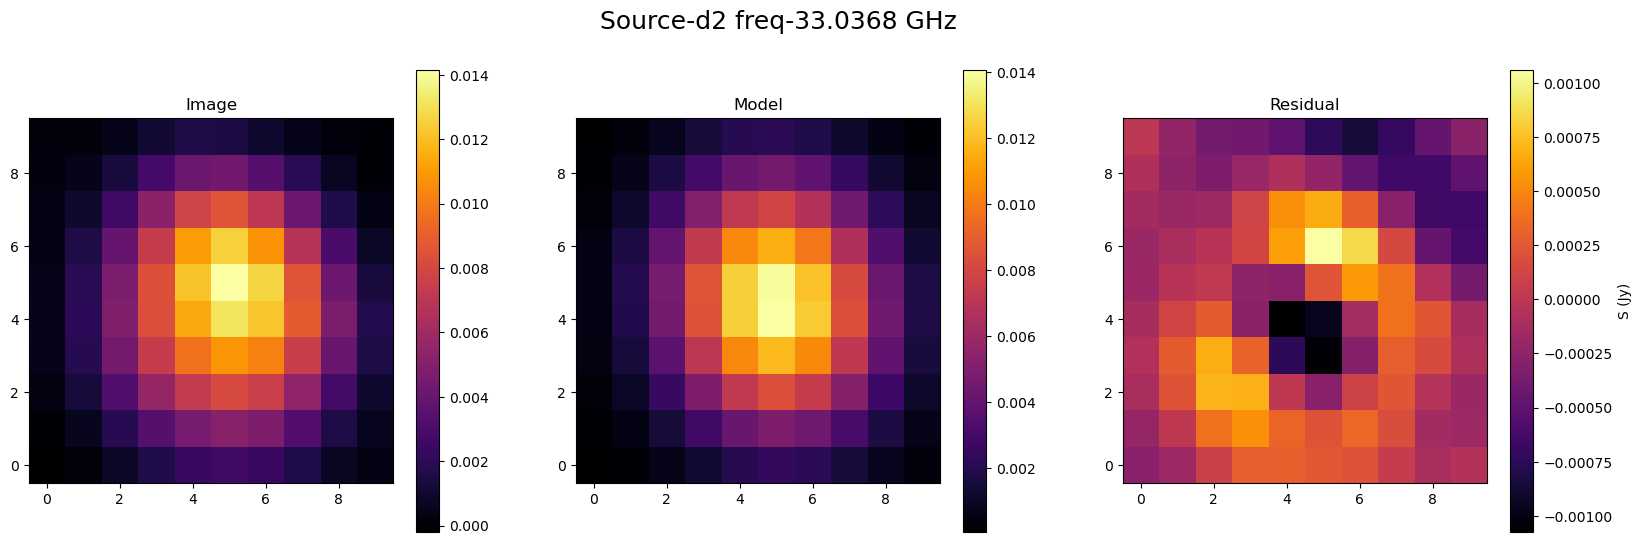

Parameter Error

Amplitude

1.431713693e-02 7.768683618e-04

x_mean

5.218963771e+03 1.069167482e-01

y_mean

4.959446872e+03 1.275303686e-01

x_stddev

2.362505537e+00 1.350391613e-01

y_stddev

1.985948994e+00 1.084625095e-01

theta

1.702578702e+00 2.204447499e-01

<SkyCoord (FK5: equinox=2000.0): (ra, dec) in deg
    (290.93836804, 14.49733844)>


/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_36096/1725868750.py:160: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  maser_table = pd.concat([maser_table, new_row], ignore_index=True)


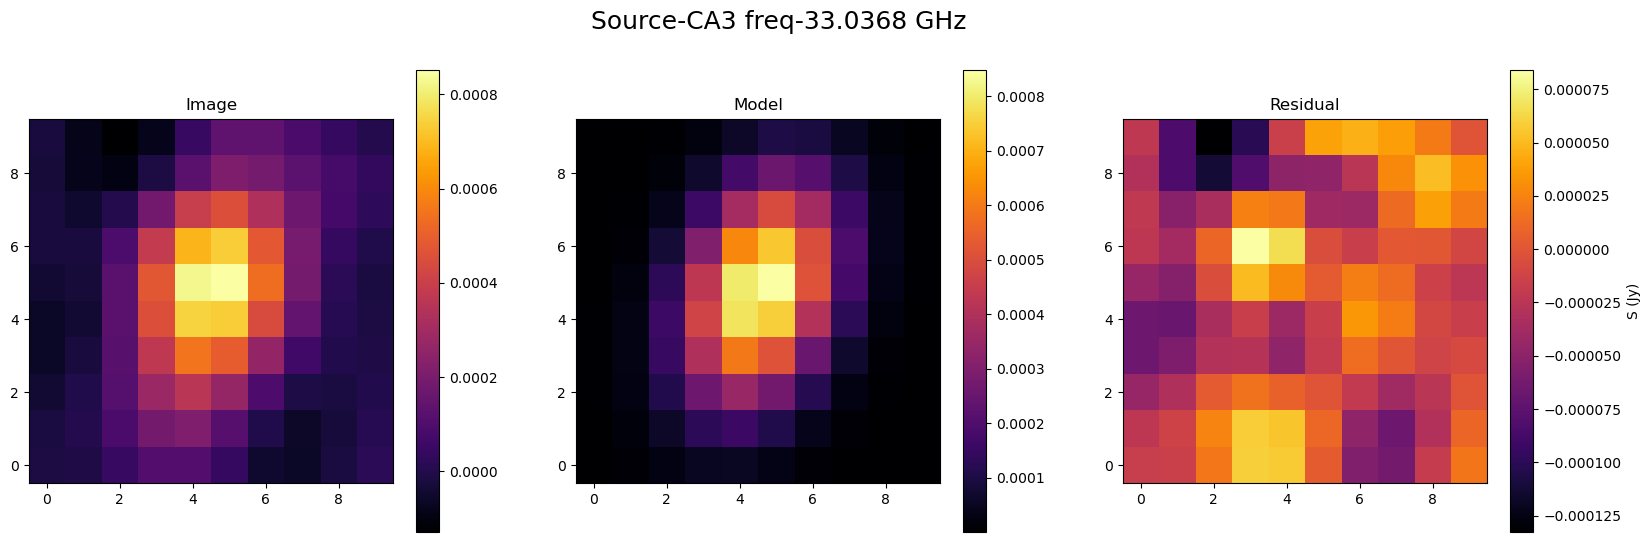

Parameter Error

Amplitude

8.911596611e-04 1.016595052e-04

x_mean

4.948565609e+03 1.580022952e-01

y_mean

5.014786831e+03 2.327257824e-01

x_stddev

2.104487219e+00 2.442272007e-01

y_stddev

1.293454856e+00 1.469801164e-01

theta

1.068304011e+01 1.594514852e-01

<SkyCoord (FK5: equinox=2000.0): (ra, dec) in deg
    (290.93836782, 14.49733887)>


In [8]:
ca3_positions_Kaband = pd.DataFrame(columns=['source','freq', 'x_pix', 'y_pix', 'amplitude', 'amplitude_error', 
'x_mean', 'x_mean_error', 'y_mean', 'y_mean_error', 'x_mean_sky', 'x_mean_sky_error', 
'y_mean_sky', 'y_mean_sky_error', 
'ra_hms', 'dec_dms',
'SkyCoord', 'frame', 'header'])

directory3 = '/Volumes/GalagaResearch/Developer/masers/continuum/modified_VLA/W51_North_KabandAarray_cont_spws_continuum_cal_clean_2terms_robust0_selfcal2.image.tt0.pbcor.fits'

ca3_positions_Kaband = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions_Kaband,
                                          amplitude=1, x=5219, y=4960, x_stddev=2, y_stddev=3, theta=np.pi/3, 
                                          size=5, freq='33.0368 GHz', source_name='d2')

ca3_positions_Kaband = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions_Kaband,
                                          amplitude=1, x=4949, y=5015, x_stddev=3, y_stddev=3, theta=np.pi/4, 
                                          size=5, freq='33.0368 GHz', source_name='CA3')

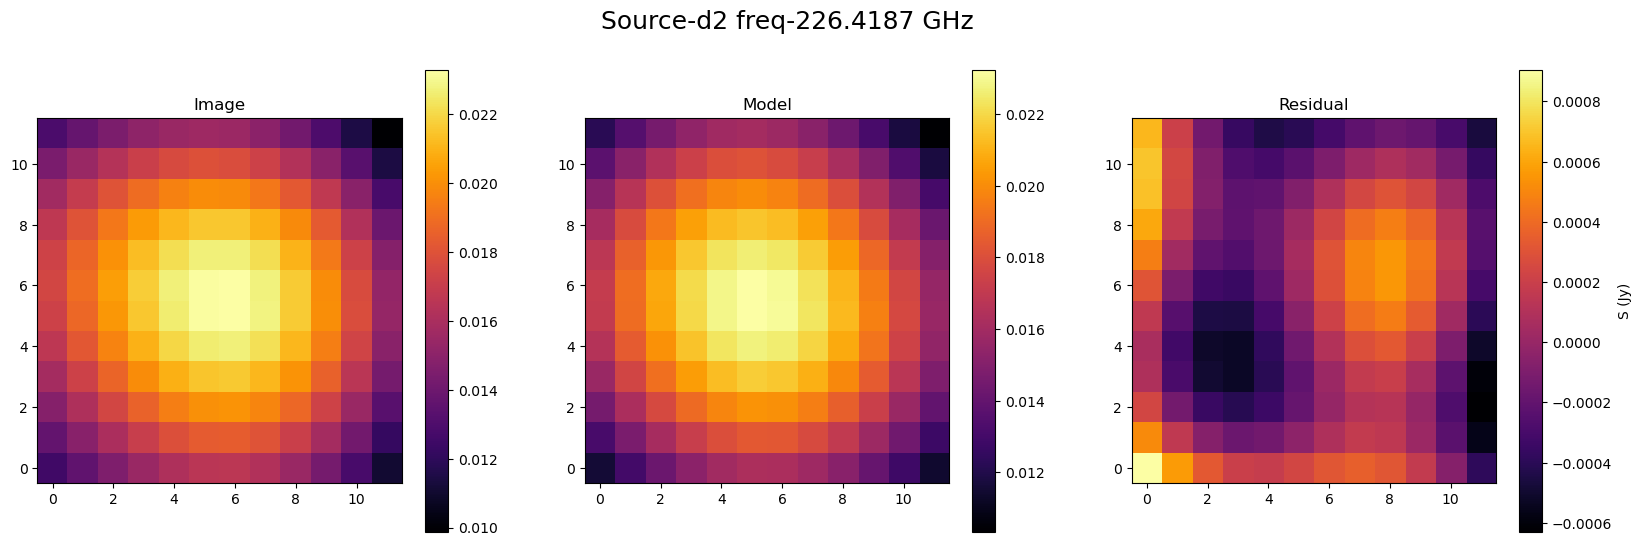

Parameter Error

Amplitude

2.3301455e-02 2.878165664e-04

x_mean

4.653145318e+03 1.026774425e-01

y_mean

3.310433439e+03 9.774275679e-02

x_stddev

6.326073193e+00 1.709450035e-01

y_stddev

6.698489883e+00 1.967723298e-01

theta

9.674320785e-01 3.798953601e-01

<SkyCoord (ICRS): (ra, dec) in deg
    (290.91991185, 14.51525451)>


/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_36096/1725868750.py:160: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  maser_table = pd.concat([maser_table, new_row], ignore_index=True)


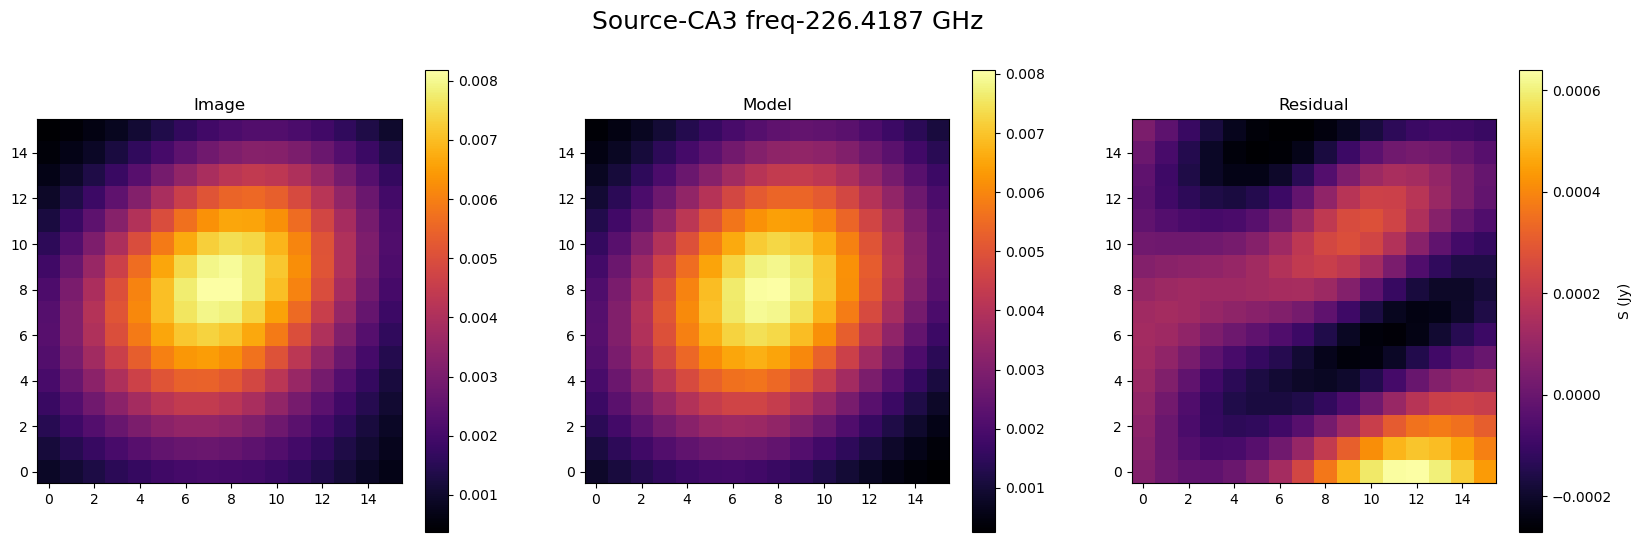

Parameter Error

Amplitude

8.098024842e-03 1.770364136e-04

x_mean

3.294575867e+03 1.028132516e-01

y_mean

3.579879019e+03 1.003013228e-01

x_stddev

4.115973080e+00 9.596429801e-02

y_stddev

5.148661666e+00 1.314115266e-01

theta

-7.116981823e+00 8.014986823e-02

<SkyCoord (ICRS): (ra, dec) in deg
    (290.91991185, 14.51525451)>


In [9]:
ca3_positions_1mm = pd.DataFrame(columns=['source','freq', 'x_pix', 'y_pix', 'amplitude', 'amplitude_error', 
'x_mean', 'x_mean_error', 'y_mean', 'y_mean_error', 'x_mean_sky', 'x_mean_sky_error', 
'y_mean_sky', 'y_mean_sky_error', 
'ra_hms', 'dec_dms',
'SkyCoord', 'frame', 'header'])

directory3 = '/Volumes/GalagaResearch/Developer/masers/continuum/W51n_cont_briggsSC_tclean.image.fits'

ca3_positions_1mm = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions_1mm,
                                          amplitude=1, x=4654, y=3311, x_stddev=2, y_stddev=3, theta=np.pi/3, 
                                          size=6, freq='226.4187 GHz', source_name='d2')

ca3_positions_1mm = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions_1mm,
                                          amplitude=1, x=3295, y=3580, x_stddev=3, y_stddev=3, theta=np.pi/4, 
                                          size=8, freq='226.4187 GHz', source_name='CA3')

In [10]:
ca3_positions_1mm

,source,freq,x_pix,y_pix,amplitude,amplitude_error,x_mean,x_mean_error,y_mean,y_mean_error,x_mean_sky,x_mean_sky_error,y_mean_sky,y_mean_sky_error,ra_hms,dec_dms,SkyCoord,frame,header
0,d2,226.4187 GHz,4654,3311,2.3301455e-02,2.878165664e-04,4.653145318e+03,1.026774425e-01,3.310433439e+03,9.774275679e-02,290.915906,290.919912,14.518013,14.515255,19:23:39.8175,14:31:04.8473,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 4\nCTYPE :...
1,CA3,226.4187 GHz,3295,3580,8.098024842e-03,1.770364136e-04,3.294575867e+03,1.028132516e-01,3.579879019e+03,1.003013228e-01,290.917076,290.919912,14.518238,14.515255,19:23:40.0982,14:31:05.6556,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 4\nCTYPE :...


In [11]:
ca3_positions_Kaband

,source,freq,x_pix,y_pix,amplitude,amplitude_error,x_mean,x_mean_error,y_mean,y_mean_error,x_mean_sky,x_mean_sky_error,y_mean_sky,y_mean_sky_error,ra_hms,dec_dms,SkyCoord,frame,header
0,d2,33.0368 GHz,5219,4960,1.431713693e-02,7.768683618e-04,5.218963771e+03,1.069167482e-01,4.959446872e+03,1.275303686e-01,290.915908,290.938368,14.518003,14.497338,19:23:39.8178,14:31:04.8117,"<SkyCoord (FK5: equinox=2000.0): (ra, dec) in ...",fk5,WCS Keywords\n\nNumber of WCS axes: 4\nCTYPE :...
1,CA3,33.0368 GHz,4949,5015,8.911596611e-04,1.016595052e-04,4.948565609e+03,1.580022952e-01,5.014786831e+03,2.327257824e-01,290.917071,290.938368,14.518234,14.497339,19:23:40.0971,14:31:05.6418,"<SkyCoord (FK5: equinox=2000.0): (ra, dec) in ...",fk5,WCS Keywords\n\nNumber of WCS axes: 4\nCTYPE :...


In [12]:
ca3_positions_Qband

,source,freq,x_pix,y_pix,amplitude,amplitude_error,x_mean,x_mean_error,y_mean,y_mean_error,x_mean_sky,x_mean_sky_error,y_mean_sky,y_mean_sky_error,ra_hms,dec_dms,SkyCoord,frame,header
0,d2,46.99 GHz,8158,7381,2.008847220e-02,7.409843248e-04,8.157326343e+03,2.127037009e-01,7.379601716e+03,2.279344148e-01,290.915907,290.927609,14.518005,14.507756,19:23:39.8177,14:31:04.8180,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...
1,CA3,46.99 GHz,7345,7544,1.118561057e-03,6.902485057e-05,7.345059411e+03,2.223309533e-01,7.543367160e+03,2.494930593e-01,290.917072,290.927609,14.518232,14.507756,19:23:40.0974,14:31:05.6368,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...


In [13]:
float(ca3_positions_Kband_size800['x_mean']), float(ca3_positions_Kband_size800['y_mean'])

/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_36096/2203283028.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(ca3_positions_Kband_size800['x_mean']), float(ca3_positions_Kband_size800['y_mean'])


(344.4824349, 415.9193021)

In [14]:
ca3_ALMA = ca3_positions[(ca3_positions['source'] == 'CA3') & (ca3_positions['freq'] == '90 GHz')]
ca3_VLA = ca3_positions[(ca3_positions['source'] == 'CA3') & (ca3_positions['freq'] == '22 GHz')]
# Delta RA
delta_ra = float(ca3_ALMA['x_mean_sky']) - ca3_positions['x_mean_sky']
delta_dec = float(ca3_ALMA['y_mean_sky']) - ca3_positions['y_mean_sky'] 

delta_diff_ca3 = np.sqrt(delta_ra**2 + delta_dec**2) 
delta_diff_ca3 = delta_diff_ca3 * u.deg.to(u.arcsec)

ca3_positions['delta_ra_ca3'] = delta_ra
ca3_positions['delta_dec_ca3'] = delta_dec
ca3_positions['delta_diff_ca3'] = delta_diff_ca3

/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_36096/2749100538.py:4: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  delta_ra = float(ca3_ALMA['x_mean_sky']) - ca3_positions['x_mean_sky']
/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_36096/2749100538.py:5: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  delta_dec = float(ca3_ALMA['y_mean_sky']) - ca3_positions['y_mean_sky']


In [15]:
ca3_VLA_Kaband = ca3_positions_Kaband[(ca3_positions_Kaband['source'] == 'CA3') & (ca3_positions_Kaband['freq'] == '33.0368 GHz')]
ca3_VLA_Qband = ca3_positions_Qband[(ca3_positions_Qband['source'] == 'CA3') & (ca3_positions_Qband['freq'] == '46.99 GHz')]

In [16]:
ca3_positions['x_mean'].astype(float)

0    5218.615043
1    4979.243042
2    4948.413209
3    4929.290048
4    4939.095581
5    7628.300477
6    7114.766666
7    7047.203990
8    7007.404004
9    7027.847385
Name: x_mean, dtype: float64

In [17]:
# 3mm ALMA sources (CRVALn)
print(np.mean(ca3_positions[(ca3_positions['freq'] == '90 GHz')]['x_mean_sky']), np.std(ca3_positions[(ca3_positions['freq'] == '90 GHz')]['x_mean_sky']))
print(np.mean(ca3_positions[(ca3_positions['freq'] == '90 GHz')]['y_mean_sky']), np.std(ca3_positions[(ca3_positions['freq'] == '90 GHz')]['y_mean_sky']))

# 1.3cm VLA sources (CRPIXn)
print(np.mean(ca3_positions[(ca3_positions['freq'] == '22 GHz')]['x_mean'].astype(float)), np.std(ca3_positions[(ca3_positions['freq'] == '22 GHz')]['x_mean'].astype(float)))
print(np.mean(ca3_positions[(ca3_positions['freq'] == '22 GHz')]['y_mean'].astype(float)), np.std(ca3_positions[(ca3_positions['freq'] == '22 GHz')]['y_mean'].astype(float)))


# the std of Delta ra and Delta dec are the uncertainties of CRVALn

crval1_ALMA = np.mean(ca3_positions[(ca3_positions['freq'] == '90 GHz')]['x_mean_sky']), np.std(ca3_positions[(ca3_positions['freq'] == '90 GHz')]['x_mean_sky'])
crval2_ALMA = np.mean(ca3_positions[(ca3_positions['freq'] == '90 GHz')]['y_mean_sky']), np.std(ca3_positions[(ca3_positions['freq'] == '90 GHz')]['y_mean_sky'])

# 1.3cm VLA sources (CRPIXn)
crpix1_VLA = np.mean(ca3_positions[(ca3_positions['freq'] == '22 GHz')]['x_mean'].astype(float)), np.std(ca3_positions[(ca3_positions['freq'] == '22 GHz')]['x_mean'].astype(float))
crpix2_VLA = np.mean(ca3_positions[(ca3_positions['freq'] == '22 GHz')]['y_mean'].astype(float)), np.std(ca3_positions[(ca3_positions['freq'] == '22 GHz')]['y_mean'].astype(float))


290.916837186342 0.00047079178350224927
14.518116598639361 0.0001428464008780475
5002.9313846000005 109.1337398096368
4985.960563799999 34.592506918272214


In [18]:
print(np.mean(ca3_positions[(ca3_positions['freq'] == '90 GHz')]['delta_ra_ca3']), np.std(ca3_positions[(ca3_positions['freq'] == '90 GHz')]['delta_ra_ca3']))
print(np.mean(ca3_positions[(ca3_positions['freq'] == '90 GHz')]['delta_dec_ca3']), np.std(ca3_positions[(ca3_positions['freq'] == '90 GHz')]['delta_dec_ca3']))


0.00023681291388584215 0.00047079178350224927
0.00011788381065080955 0.0001428464008780475


In [19]:
ca3_positions

,source,freq,x_pix,y_pix,amplitude,amplitude_error,x_mean,x_mean_error,y_mean,y_mean_error,...,y_mean_sky,y_mean_sky_error,ra_hms,dec_dms,SkyCoord,frame,header,delta_ra_ca3,delta_dec_ca3,delta_diff_ca3
0,d2,22 GHz,5219,4959,1.151771352e-02,1.917987152e-04,5.218615043e+03,3.887028644e-02,4.959186077e+03,4.536435585e-02,...,14.518002,14.497338,19:23:39.8182,14:31:04.8078,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...,0.001165,2.323229e-04,4.276376
1,CB1,22 GHz,4979,5000,4.418660395e-04,2.246677133e-04,4.979243042e+03,6.90705741e-01,5.000031297e+03,9.478908986e-01,...,14.518172,14.497342,19:23:40.0654,14:31:05.4205,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...,0.000135,6.213267e-05,0.533894
2,CA3,22 GHz,4948,5015,8.69973245e-04,6.988139620e-05,4.948413209e+03,1.426088778e-01,5.014913612e+03,2.229965868e-01,...,14.518234,14.497339,19:23:40.0973,14:31:05.6437,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...,0.000002,1.231144e-07,0.007091
3,CA1,22 GHz,4929,5023,6.131044792e-04,4.511103321e-05,4.929290048e+03,2.572806573e-01,5.023102075e+03,2.51185041e-01,...,14.518268,14.497339,19:23:40.1170,14:31:05.7665,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...,-0.000080,-3.399539e-05,0.314059
4,CC1,22 GHz,4939,4933,3.381155236e-04,1.007333922e-04,4.939095581e+03,4.048591057e-01,4.932569758e+03,4.387020824e-01,...,14.517891,14.497340,19:23:40.1069,14:31:04.4085,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...,-0.000038,3.432225e-04,1.243206
5,d2,90 GHz,7628,7226,4.334628767e-02,6.406366511e-04,7.628300477e+03,6.352709685e-02,7.226089485e+03,6.643789566e-02,...,14.518009,14.503958,19:23:39.8176,14:31:04.8326,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 4\nCTYPE :...,0.001167,2.254208e-04,4.279494
6,CB1,90 GHz,7115,7311,2.173482568e-03,8.966578428e-05,7.114766666e+03,1.873506309e-01,7.311140702e+03,2.105421575e-01,...,14.518174,14.503958,19:23:40.0652,14:31:05.4280,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 4\nCTYPE :...,0.000136,6.004234e-05,0.534221
7,CA3,90 GHz,7047,7342,3.864660335e-03,9.373147247e-05,7.04720399e+03,8.854048944e-02,7.342019719e+03,9.496941747e-02,...,14.518234,14.503958,19:23:40.0978,14:31:05.6441,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 4\nCTYPE :...,0.000000,0.000000e+00,0.000000
8,CA1,90 GHz,7008,7361,2.128559589e-03,6.407895672e-05,7.007404004e+03,1.244989264e-01,7.360686341e+03,1.227562253e-01,...,14.518271,14.503958,19:23:40.1169,14:31:05.7748,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 4\nCTYPE :...,-0.000080,-3.629606e-05,0.316064
9,CC1,90 GHz,7028,7167,1.76969183e-03,1.845949664e-05,7.027847385e+03,3.562377766e-02,7.167033011e+03,3.648030928e-02,...,14.517894,14.503958,19:23:40.1071,14:31:04.4192,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 4\nCTYPE :...,-0.000039,3.402520e-04,1.232878


In [20]:
ca3_positions

,source,freq,x_pix,y_pix,amplitude,amplitude_error,x_mean,x_mean_error,y_mean,y_mean_error,...,y_mean_sky,y_mean_sky_error,ra_hms,dec_dms,SkyCoord,frame,header,delta_ra_ca3,delta_dec_ca3,delta_diff_ca3
0,d2,22 GHz,5219,4959,1.151771352e-02,1.917987152e-04,5.218615043e+03,3.887028644e-02,4.959186077e+03,4.536435585e-02,...,14.518002,14.497338,19:23:39.8182,14:31:04.8078,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...,0.001165,2.323229e-04,4.276376
1,CB1,22 GHz,4979,5000,4.418660395e-04,2.246677133e-04,4.979243042e+03,6.90705741e-01,5.000031297e+03,9.478908986e-01,...,14.518172,14.497342,19:23:40.0654,14:31:05.4205,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...,0.000135,6.213267e-05,0.533894
2,CA3,22 GHz,4948,5015,8.69973245e-04,6.988139620e-05,4.948413209e+03,1.426088778e-01,5.014913612e+03,2.229965868e-01,...,14.518234,14.497339,19:23:40.0973,14:31:05.6437,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...,0.000002,1.231144e-07,0.007091
3,CA1,22 GHz,4929,5023,6.131044792e-04,4.511103321e-05,4.929290048e+03,2.572806573e-01,5.023102075e+03,2.51185041e-01,...,14.518268,14.497339,19:23:40.1170,14:31:05.7665,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...,-0.000080,-3.399539e-05,0.314059
4,CC1,22 GHz,4939,4933,3.381155236e-04,1.007333922e-04,4.939095581e+03,4.048591057e-01,4.932569758e+03,4.387020824e-01,...,14.517891,14.497340,19:23:40.1069,14:31:04.4085,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...,-0.000038,3.432225e-04,1.243206
5,d2,90 GHz,7628,7226,4.334628767e-02,6.406366511e-04,7.628300477e+03,6.352709685e-02,7.226089485e+03,6.643789566e-02,...,14.518009,14.503958,19:23:39.8176,14:31:04.8326,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 4\nCTYPE :...,0.001167,2.254208e-04,4.279494
6,CB1,90 GHz,7115,7311,2.173482568e-03,8.966578428e-05,7.114766666e+03,1.873506309e-01,7.311140702e+03,2.105421575e-01,...,14.518174,14.503958,19:23:40.0652,14:31:05.4280,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 4\nCTYPE :...,0.000136,6.004234e-05,0.534221
7,CA3,90 GHz,7047,7342,3.864660335e-03,9.373147247e-05,7.04720399e+03,8.854048944e-02,7.342019719e+03,9.496941747e-02,...,14.518234,14.503958,19:23:40.0978,14:31:05.6441,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 4\nCTYPE :...,0.000000,0.000000e+00,0.000000
8,CA1,90 GHz,7008,7361,2.128559589e-03,6.407895672e-05,7.007404004e+03,1.244989264e-01,7.360686341e+03,1.227562253e-01,...,14.518271,14.503958,19:23:40.1169,14:31:05.7748,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 4\nCTYPE :...,-0.000080,-3.629606e-05,0.316064
9,CC1,90 GHz,7028,7167,1.76969183e-03,1.845949664e-05,7.027847385e+03,3.562377766e-02,7.167033011e+03,3.648030928e-02,...,14.517894,14.503958,19:23:40.1071,14:31:04.4192,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 4\nCTYPE :...,-0.000039,3.402520e-04,1.232878


In [21]:
x_mean_sky_90 = ca3_positions[(ca3_positions['freq'] == '90 GHz')]['x_mean_sky']
x_mean_sky_22 = ca3_positions[(ca3_positions['freq'] == '22 GHz')]['x_mean_sky']
y_mean_sky_90 = ca3_positions[(ca3_positions['freq'] == '90 GHz')]['y_mean_sky']
y_mean_sky_22 = ca3_positions[(ca3_positions['freq'] == '22 GHz')]['y_mean_sky']

delta_ra_each = np.array(x_mean_sky_90) - np.array(x_mean_sky_22)
delta_dec_each = np.array(y_mean_sky_90) - np.array(y_mean_sky_22)

np.mean(delta_ra_each), np.mean(delta_dec_each)

(np.float64(-1.9508920559019317e-07), np.float64(2.877367797893271e-06))

In [22]:
d2_22GHz_bool = (ca3_positions['source'] == 'd2') & (ca3_positions['freq'] == '22 GHz')
d2_90GHz_bool = (ca3_positions['source'] == 'd2') & (ca3_positions['freq'] == '90 GHz')

d2_22GHz_coord = ca3_positions.loc[d2_22GHz_bool, 'SkyCoord'].squeeze()
d2_90GHz_coord = ca3_positions.loc[d2_90GHz_bool, 'SkyCoord'].squeeze()

d2_22GHz_coord.separation(d2_90GHz_coord).arcsec

np.float64(0.02604249781582252)

In [23]:
def compute_separations(df, freq1='22 GHz', freq2='90 GHz'):

    results = []
    sources = df['source'].unique()
    for source in sources:
        group = df[df['source'] == source]
        # Check that there is at least one row for each frequency.
        if (group['freq'] == freq1).any() and (group['freq'] == freq2).any():
            # Use .squeeze() to extract a scalar SkyCoord if only one row per frequency
            coord1 = group.loc[group['freq'] == freq1, 'SkyCoord'].squeeze()
            coord2 = group.loc[group['freq'] == freq2, 'SkyCoord'].squeeze()
            # Compute the separation
            separation = coord1.separation(coord2).arcsec
            results.append({'source': source, 'separation_arcsec': separation})
    separation_df = pd.DataFrame(results)
    return separation_df

In [24]:
def compute_differences(df, freq1='22 GHz', freq2='90 GHz'):

    difference_distance_list = []

    sources = df['source'].unique()
    for source in sources:
        group = df[df['source'] == source]
        # Check that there is at least one row for each frequency.
        if (group['freq'] == freq1).any() and (group['freq'] == freq2).any():
            # Use .squeeze() to extract a scalar SkyCoord if only one row per frequency
            ra1 = group.loc[group['freq'] == freq1, 'x_mean_sky'].squeeze()
            dec1 = group.loc[group['freq'] == freq1, 'y_mean_sky'].squeeze()

            ra2 = group.loc[group['freq'] == freq2, 'x_mean_sky'].squeeze()
            dec2 = group.loc[group['freq'] == freq2, 'y_mean_sky'].squeeze()

            delta_ra = ra2 - ra1
            delta_dec = dec2 - dec1

            diff_distance = np.sqrt(delta_ra**2 + delta_dec**2) * u.deg.to(u.arcsec)

            difference_distance_list.append({'source': source, 'delta_distance_arcsec': diff_distance})

    difference_distance_df = pd.DataFrame(difference_distance_list)

    return difference_distance_df

In [51]:
#Separation between 22 GHz and 90 GHz

compute_separations(ca3_positions), compute_differences(ca3_positions)

(  source  separation_arcsec
 0     d2           0.026042
 1    CB1           0.008359
 2    CA3           0.006866
 3    CA1           0.008399
 4    CC1           0.011001,
   source  delta_distance_arcsec
 0     d2               0.026121
 1    CB1               0.008412
 2    CA3               0.007091
 3    CA1               0.008407
 4    CC1               0.011022)

In [53]:
np.mean(compute_separations(ca3_positions)['separation_arcsec'])

np.float64(0.012133620396366677)

In [26]:
np.mean(compute_separations(ca3_positions)['separation_arcsec']), np.mean(compute_differences(ca3_positions)['delta_distance_arcsec'])

(np.float64(0.012133620396366677), np.float64(0.012210570431839948))

In [27]:
ca3_positions

,source,freq,x_pix,y_pix,amplitude,amplitude_error,x_mean,x_mean_error,y_mean,y_mean_error,...,y_mean_sky,y_mean_sky_error,ra_hms,dec_dms,SkyCoord,frame,header,delta_ra_ca3,delta_dec_ca3,delta_diff_ca3
0,d2,22 GHz,5219,4959,1.151771352e-02,1.917987152e-04,5.218615043e+03,3.887028644e-02,4.959186077e+03,4.536435585e-02,...,14.518002,14.497338,19:23:39.8182,14:31:04.8078,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...,0.001165,2.323229e-04,4.276376
1,CB1,22 GHz,4979,5000,4.418660395e-04,2.246677133e-04,4.979243042e+03,6.90705741e-01,5.000031297e+03,9.478908986e-01,...,14.518172,14.497342,19:23:40.0654,14:31:05.4205,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...,0.000135,6.213267e-05,0.533894
2,CA3,22 GHz,4948,5015,8.69973245e-04,6.988139620e-05,4.948413209e+03,1.426088778e-01,5.014913612e+03,2.229965868e-01,...,14.518234,14.497339,19:23:40.0973,14:31:05.6437,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...,0.000002,1.231144e-07,0.007091
3,CA1,22 GHz,4929,5023,6.131044792e-04,4.511103321e-05,4.929290048e+03,2.572806573e-01,5.023102075e+03,2.51185041e-01,...,14.518268,14.497339,19:23:40.1170,14:31:05.7665,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...,-0.000080,-3.399539e-05,0.314059
4,CC1,22 GHz,4939,4933,3.381155236e-04,1.007333922e-04,4.939095581e+03,4.048591057e-01,4.932569758e+03,4.387020824e-01,...,14.517891,14.497340,19:23:40.1069,14:31:04.4085,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...,-0.000038,3.432225e-04,1.243206
5,d2,90 GHz,7628,7226,4.334628767e-02,6.406366511e-04,7.628300477e+03,6.352709685e-02,7.226089485e+03,6.643789566e-02,...,14.518009,14.503958,19:23:39.8176,14:31:04.8326,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 4\nCTYPE :...,0.001167,2.254208e-04,4.279494
6,CB1,90 GHz,7115,7311,2.173482568e-03,8.966578428e-05,7.114766666e+03,1.873506309e-01,7.311140702e+03,2.105421575e-01,...,14.518174,14.503958,19:23:40.0652,14:31:05.4280,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 4\nCTYPE :...,0.000136,6.004234e-05,0.534221
7,CA3,90 GHz,7047,7342,3.864660335e-03,9.373147247e-05,7.04720399e+03,8.854048944e-02,7.342019719e+03,9.496941747e-02,...,14.518234,14.503958,19:23:40.0978,14:31:05.6441,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 4\nCTYPE :...,0.000000,0.000000e+00,0.000000
8,CA1,90 GHz,7008,7361,2.128559589e-03,6.407895672e-05,7.007404004e+03,1.244989264e-01,7.360686341e+03,1.227562253e-01,...,14.518271,14.503958,19:23:40.1169,14:31:05.7748,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 4\nCTYPE :...,-0.000080,-3.629606e-05,0.316064
9,CC1,90 GHz,7028,7167,1.76969183e-03,1.845949664e-05,7.027847385e+03,3.562377766e-02,7.167033011e+03,3.648030928e-02,...,14.517894,14.503958,19:23:40.1071,14:31:04.4192,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 4\nCTYPE :...,-0.000039,3.402520e-04,1.232878


In [28]:
ca3_positions

,source,freq,x_pix,y_pix,amplitude,amplitude_error,x_mean,x_mean_error,y_mean,y_mean_error,...,y_mean_sky,y_mean_sky_error,ra_hms,dec_dms,SkyCoord,frame,header,delta_ra_ca3,delta_dec_ca3,delta_diff_ca3
0,d2,22 GHz,5219,4959,1.151771352e-02,1.917987152e-04,5.218615043e+03,3.887028644e-02,4.959186077e+03,4.536435585e-02,...,14.518002,14.497338,19:23:39.8182,14:31:04.8078,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...,0.001165,2.323229e-04,4.276376
1,CB1,22 GHz,4979,5000,4.418660395e-04,2.246677133e-04,4.979243042e+03,6.90705741e-01,5.000031297e+03,9.478908986e-01,...,14.518172,14.497342,19:23:40.0654,14:31:05.4205,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...,0.000135,6.213267e-05,0.533894
2,CA3,22 GHz,4948,5015,8.69973245e-04,6.988139620e-05,4.948413209e+03,1.426088778e-01,5.014913612e+03,2.229965868e-01,...,14.518234,14.497339,19:23:40.0973,14:31:05.6437,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...,0.000002,1.231144e-07,0.007091
3,CA1,22 GHz,4929,5023,6.131044792e-04,4.511103321e-05,4.929290048e+03,2.572806573e-01,5.023102075e+03,2.51185041e-01,...,14.518268,14.497339,19:23:40.1170,14:31:05.7665,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...,-0.000080,-3.399539e-05,0.314059
4,CC1,22 GHz,4939,4933,3.381155236e-04,1.007333922e-04,4.939095581e+03,4.048591057e-01,4.932569758e+03,4.387020824e-01,...,14.517891,14.497340,19:23:40.1069,14:31:04.4085,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...,-0.000038,3.432225e-04,1.243206
5,d2,90 GHz,7628,7226,4.334628767e-02,6.406366511e-04,7.628300477e+03,6.352709685e-02,7.226089485e+03,6.643789566e-02,...,14.518009,14.503958,19:23:39.8176,14:31:04.8326,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 4\nCTYPE :...,0.001167,2.254208e-04,4.279494
6,CB1,90 GHz,7115,7311,2.173482568e-03,8.966578428e-05,7.114766666e+03,1.873506309e-01,7.311140702e+03,2.105421575e-01,...,14.518174,14.503958,19:23:40.0652,14:31:05.4280,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 4\nCTYPE :...,0.000136,6.004234e-05,0.534221
7,CA3,90 GHz,7047,7342,3.864660335e-03,9.373147247e-05,7.04720399e+03,8.854048944e-02,7.342019719e+03,9.496941747e-02,...,14.518234,14.503958,19:23:40.0978,14:31:05.6441,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 4\nCTYPE :...,0.000000,0.000000e+00,0.000000
8,CA1,90 GHz,7008,7361,2.128559589e-03,6.407895672e-05,7.007404004e+03,1.244989264e-01,7.360686341e+03,1.227562253e-01,...,14.518271,14.503958,19:23:40.1169,14:31:05.7748,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 4\nCTYPE :...,-0.000080,-3.629606e-05,0.316064
9,CC1,90 GHz,7028,7167,1.76969183e-03,1.845949664e-05,7.027847385e+03,3.562377766e-02,7.167033011e+03,3.648030928e-02,...,14.517894,14.503958,19:23:40.1071,14:31:04.4192,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 4\nCTYPE :...,-0.000039,3.402520e-04,1.232878


In [29]:
float(ca3_ALMA['x_mean_sky'])

/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_36096/3816414553.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(ca3_ALMA['x_mean_sky'])


290.9170739992559

In [30]:
ca3_ALMA['x_mean_sky']

7    290.917074
Name: x_mean_sky, dtype: float64

In [31]:
pwd

'/Volumes/GalagaResearch/Developer/masers/W51/W51-Masers-and-Starforming-Regions/notebooks/FK5_ICRS_offsets'

In [32]:
float(ca3_ALMA['x_mean_sky'])

/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_36096/3816414553.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(ca3_ALMA['x_mean_sky'])


290.9170739992559

In [33]:
ca3_positions.to_csv('offset_sources.csv', index=False)

### Edit Headers of VLA files

In [34]:
import glob
import os

In [35]:
# Change K Band FK5 to ICRS

all_fits = glob.glob('/Volumes/GalagaResearch/Developer/masers/continuum/modified_VLA/W51_North_KbandAarray_cont_spws_continuum_cal_clean_2terms_robust0_selfcal3.image.tt0.pbcor.fits')

for fits_path in all_fits:
    with fits.open(fits_path) as hdul:
        hdr = hdul[0].header
        hdr['RADESYS'] = 'ICRS'
    
        if 'EQUINOX' in hdr:
            del hdr['EQUINOX']

        # ALMA ICRS CA3 physical coordinates 
        hdr['CRVAL1'] = float(ca3_ALMA['x_mean_sky'])
        hdr['CRVAL2'] = float(ca3_ALMA['y_mean_sky'])

        # VLA CA3 pixel coordinates
        hdr['CRPIX1'] = float(ca3_VLA['x_mean'])
        hdr['CRPIX2'] = float(ca3_VLA['y_mean'])

        base_name = os.path.splitext(fits_path)[0]  # Remove the .fits part
        new_fits_file = f"{base_name}_ICRS_CRVAL_CA3_crval_change.fits"

        hdul.writeto(new_fits_file, overwrite=True)


    print(f"Modified and saved: {new_fits_file}")

/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_36096/1206931739.py:14: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  hdr['CRVAL1'] = float(ca3_ALMA['x_mean_sky'])
/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_36096/1206931739.py:15: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  hdr['CRVAL2'] = float(ca3_ALMA['y_mean_sky'])
/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_36096/1206931739.py:18: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  hdr['CRPIX1'] = float(ca3_VLA['x_mean'])
/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_36096/1206931739.py:19: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in 

Modified and saved: /Volumes/GalagaResearch/Developer/masers/continuum/modified_VLA/W51_North_KbandAarray_cont_spws_continuum_cal_clean_2terms_robust0_selfcal3.image.tt0.pbcor_ICRS_CRVAL_CA3_crval_change.fits


In [36]:
# Ka Band

all_fits = glob.glob('/Volumes/GalagaResearch/Developer/masers/continuum/modified_VLA/W51_North_KabandAarray_cont_spws_continuum_cal_clean_2terms_robust0_selfcal2.image.tt0.pbcor.fits')

for fits_path in all_fits:
    with fits.open(fits_path) as hdul:
        hdr = hdul[0].header
        hdr['RADESYS'] = 'ICRS'
    
        if 'EQUINOX' in hdr:
            del hdr['EQUINOX']

        # ALMA ICRS CA3 physical coordinates 
        hdr['CRVAL1'] = float(ca3_ALMA['x_mean_sky'])
        hdr['CRVAL2'] = float(ca3_ALMA['y_mean_sky'])

        # VLA CA3 pixel coordinates
        hdr['CRPIX1'] = float(ca3_VLA_Kaband['x_mean'])
        hdr['CRPIX2'] = float(ca3_VLA_Kaband['y_mean'])

        base_name = os.path.splitext(fits_path)[0]  # Remove the .fits part
        new_fits_file = f"{base_name}_ICRS_CRVAL_CA3_crval_change.fits"

        hdul.writeto(new_fits_file, overwrite=True)


    print(f"Modified and saved: {new_fits_file}")

/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_36096/1829368604.py:14: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  hdr['CRVAL1'] = float(ca3_ALMA['x_mean_sky'])
/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_36096/1829368604.py:15: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  hdr['CRVAL2'] = float(ca3_ALMA['y_mean_sky'])
/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_36096/1829368604.py:18: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  hdr['CRPIX1'] = float(ca3_VLA_Kaband['x_mean'])
/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_36096/1829368604.py:19: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeEr

Modified and saved: /Volumes/GalagaResearch/Developer/masers/continuum/modified_VLA/W51_North_KabandAarray_cont_spws_continuum_cal_clean_2terms_robust0_selfcal2.image.tt0.pbcor_ICRS_CRVAL_CA3_crval_change.fits


In [41]:
# Q Band

all_fits = glob.glob('/Volumes/GalagaResearch/Developer/masers/continuum/modified_VLA/W51_North_QbandAarray_cont_spws_continuum_cal_clean_2terms_robust0_selfcal4_final.image.tt0.pbcor.fits')

for fits_path in all_fits:
    with fits.open(fits_path) as hdul:
        hdr = hdul[0].header
        hdr['RADESYS'] = 'ICRS'
    
        if 'EQUINOX' in hdr:
            del hdr['EQUINOX']

        # ALMA ICRS CA3 physical coordinates 
        hdr['CRVAL1'] = float(ca3_ALMA['x_mean_sky'])
        hdr['CRVAL2'] = float(ca3_ALMA['y_mean_sky'])

        # VLA CA3 pixel coordinates
        hdr['CRPIX1'] = float(ca3_VLA_Qband['x_mean'])
        hdr['CRPIX2'] = float(ca3_VLA_Qband['y_mean'])

        base_name = os.path.splitext(fits_path)[0]  # Remove the .fits part
        new_fits_file = f"{base_name}_ICRS_CRVAL_CA3_crval_change.fits"

        hdul.writeto(new_fits_file, overwrite=True)


    print(f"Modified and saved: {new_fits_file}")

/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_36096/2798985234.py:14: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  hdr['CRVAL1'] = float(ca3_ALMA['x_mean_sky'])
/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_36096/2798985234.py:15: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  hdr['CRVAL2'] = float(ca3_ALMA['y_mean_sky'])
/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_36096/2798985234.py:18: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  hdr['CRPIX1'] = float(ca3_VLA_Qband['x_mean'])
/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_36096/2798985234.py:19: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeErr

Modified and saved: /Volumes/GalagaResearch/Developer/masers/continuum/modified_VLA/W51_North_QbandAarray_cont_spws_continuum_cal_clean_2terms_robust0_selfcal4_final.image.tt0.pbcor_ICRS_CRVAL_CA3_crval_change.fits


In [38]:
# Change K Band FK5 to ICRS

all_fits = glob.glob('/Volumes/GalagaResearch/Developer/masers/continuum/modified_VLA/W51_North_KbandAarray_cont_spws_continuum_cal_clean_2terms_robust0_selfcal3.image.tt0.pbcor.fits')

for fits_path in all_fits:
    with fits.open(fits_path) as hdul:
        hdr = hdul[0].header
        hdr['RADESYS'] = 'ICRS'
    
        if 'EQUINOX' in hdr:
            del hdr['EQUINOX']

        # ALMA ICRS CA3 physical coordinates 
        hdr['CRVAL1'] = float(ca3_ALMA['x_mean_sky'])
        hdr['CRVAL2'] = float(ca3_ALMA['y_mean_sky'])

        # VLA CA3 pixel coordinates
        hdr['CRPIX1'] = float(ca3_VLA['x_mean'])
        hdr['CRPIX2'] = float(ca3_VLA['y_mean'])

        base_name = os.path.splitext(fits_path)[0]  # Remove the .fits part
        new_fits_file = f"{base_name}_ICRS_CRVAL_CA3_crval_change.fits"

        hdul.writeto(new_fits_file, overwrite=True)


    print(f"Modified and saved: {new_fits_file}")

/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_36096/1206931739.py:14: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  hdr['CRVAL1'] = float(ca3_ALMA['x_mean_sky'])
/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_36096/1206931739.py:15: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  hdr['CRVAL2'] = float(ca3_ALMA['y_mean_sky'])
/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_36096/1206931739.py:18: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  hdr['CRPIX1'] = float(ca3_VLA['x_mean'])
/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_36096/1206931739.py:19: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in 

Modified and saved: /Volumes/GalagaResearch/Developer/masers/continuum/modified_VLA/W51_North_KbandAarray_cont_spws_continuum_cal_clean_2terms_robust0_selfcal3.image.tt0.pbcor_ICRS_CRVAL_CA3_crval_change.fits


In [39]:
# Change K Band FK5 to ICRS

all_fits = glob.glob('/Volumes/GalagaResearch/Developer/masers/continuum/W51North_Kband_continuum_aug02.image.fits')

for fits_path in all_fits:
    with fits.open(fits_path) as hdul:
        hdr = hdul[0].header
        hdr['RADESYS'] = 'ICRS'
    
        if 'EQUINOX' in hdr:
            del hdr['EQUINOX']

        # ALMA ICRS CA3 physical coordinates 
        hdr['CRVAL1'] = float(ca3_ALMA['x_mean_sky'])
        hdr['CRVAL2'] = float(ca3_ALMA['y_mean_sky'])

        # VLA CA3 pixel coordinates
        hdr['CRPIX1'] = float(ca3_positions_Kband_size800['x_mean'])
        hdr['CRPIX2'] = float(ca3_positions_Kband_size800['y_mean'])

        base_name = os.path.splitext(fits_path)[0]  # Remove the .fits part
        new_fits_file = f"{base_name}_ICRS_CRVAL_CA3_crval_change.fits"

        hdul.writeto(new_fits_file, overwrite=True)


    print(f"Modified and saved: {new_fits_file}")

Modified and saved: /Volumes/GalagaResearch/Developer/masers/continuum/W51North_Kband_continuum_aug02.image_ICRS_CRVAL_CA3_crval_change.fits


/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_36096/530818468.py:14: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  hdr['CRVAL1'] = float(ca3_ALMA['x_mean_sky'])
/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_36096/530818468.py:15: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  hdr['CRVAL2'] = float(ca3_ALMA['y_mean_sky'])
/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_36096/530818468.py:18: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  hdr['CRPIX1'] = float(ca3_positions_Kband_size800['x_mean'])
/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_36096/530818468.py:19: FutureWarning: Calling float on a single element Series is deprecated and will raise

In [40]:
# Masers

# /Volumes/GalagaResearch/Developer/masers/W51/FITS/original/

all_fits = glob.glob('/Volumes/GalagaResearch/Developer/masers/W51/FITS/original/*_aug_02.fits')

for fits_path in all_fits:
    with fits.open(fits_path) as hdul:
        hdr = hdul[0].header
        hdr['RADESYS'] = 'ICRS'
    
        if 'EQUINOX' in hdr:
            del hdr['EQUINOX']

        # ALMA ICRS CA3 physical coordinates 
        hdr['CRVAL1'] = float(ca3_ALMA['x_mean_sky'])
        hdr['CRVAL2'] = float(ca3_ALMA['y_mean_sky'])

        # VLA CA3 pixel coordinates
        # hdr['CRPIX1'] = int(float(ca3_VLA['x_mean']))
        # hdr['CRPIX2'] = int(float(ca3_VLA['y_mean']))
        
        hdr['CRPIX1'] = float(ca3_positions_Kband_size800['x_mean'])
        hdr['CRPIX2'] = float(ca3_positions_Kband_size800['y_mean'])

        base_name = os.path.splitext(fits_path)[0]  # Remove the .fits part
        new_fits_file = f"{base_name}_ICRS_CRVAL_CA3_crval_change.fits"

        hdul.writeto(new_fits_file, overwrite=True)

    print(f"Modified and saved: {new_fits_file}")

/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_36096/3295870171.py:16: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  hdr['CRVAL1'] = float(ca3_ALMA['x_mean_sky'])
/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_36096/3295870171.py:17: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  hdr['CRVAL2'] = float(ca3_ALMA['y_mean_sky'])
/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_36096/3295870171.py:23: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  hdr['CRPIX1'] = float(ca3_positions_Kband_size800['x_mean'])
/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_36096/3295870171.py:24: FutureWarning: Calling float on a single element Series is deprecated and will r

Modified and saved: /Volumes/GalagaResearch/Developer/masers/W51/FITS/original/W51North_spw_53_corrected2_aug_02_ICRS_CRVAL_CA3_crval_change.fits
Modified and saved: /Volumes/GalagaResearch/Developer/masers/W51/FITS/original/W51North_spw_6_corrected11_1_aug_02_ICRS_CRVAL_CA3_crval_change.fits
Modified and saved: /Volumes/GalagaResearch/Developer/masers/W51/FITS/original/W51North_spw_38_corrected6_aug_02_ICRS_CRVAL_CA3_crval_change.fits
Modified and saved: /Volumes/GalagaResearch/Developer/masers/W51/FITS/original/W51North_spw_50_corrected2_aug_02_ICRS_CRVAL_CA3_crval_change.fits
Modified and saved: /Volumes/GalagaResearch/Developer/masers/W51/FITS/original/W51North_spw_28_corrected31_aug_02_ICRS_CRVAL_CA3_crval_change.fits
Modified and saved: /Volumes/GalagaResearch/Developer/masers/W51/FITS/original/W51North_spw_56_corrected2_aug_02_ICRS_CRVAL_CA3_crval_change.fits
Modified and saved: /Volumes/GalagaResearch/Developer/masers/W51/FITS/original/W51North_spw_28_corrected40_aug_02_ICRS_CR